<a href="https://colab.research.google.com/github/javmencia/ReSTORELab/blob/main/LSTMfinalversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

720 day work disability model

In [4]:
import pandas as pd
data = pd.read_csv('sledatacutsdi.csv', parse_dates=['ASSDT'])
data.columns.tolist()

/tmp/ipython-input-263122655.py:2: DtypeWarning: Columns (136,138,145,147,154,156,161) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacutsdi.csv', parse_dates=['ASSDT'])


['PTNO',
 'BIRTHDT',
 'SEX',
 'DATEOFDX',
 'RACE',
 'LCDT',
 'STATUS',
 'DEATHDT',
 'INCEPT',
 'ID',
 'ASSDT',
 'EMP',
 'visit_num',
 'total_visits',
 'startdate',
 'time_first_last',
 'time_between',
 'EMPf',
 'initial_emp',
 'final_emp',
 'visit_num96',
 'total_visits96',
 'time_first_last96',
 'time_between96',
 'changed',
 'time_to_first_change',
 'SLED1_I',
 'SLED2_I',
 'SLED3_I',
 'SLED4_I',
 'SLED5_I',
 'SLED6_I',
 'SLED7_I',
 'SLED8_I',
 'SLED9_I',
 'SLED10_I',
 'SLED11_I',
 'SLED12_I',
 'SLED13_I',
 'SLED14_I',
 'SLED15_I',
 'SLED16_I',
 'SLED17_I',
 'SLED18_I',
 'SLED19_I',
 'SLED20_I',
 'SLED21_I',
 'SLED22_I',
 'SLED23_I',
 'SLED24_I',
 'SLEDAI2_I',
 'ACATARACT',
 'RETOPT',
 'COGNIMP',
 'SEIZURX6',
 'CERVASAC',
 'CPNEUR',
 'TRANMYEL',
 'GFR50',
 'PROT24',
 'ENDRENAL',
 'PULMHYP',
 'PULMFIBR',
 'SHRINKL',
 'PLEURFIBR',
 'PULMINF',
 'ANGBYP',
 'MYOCARINF',
 'CARDMYOP',
 'VALVULAR',
 'PERICARD6',
 'CLAUDIC',
 'MINORTL',
 'SIGNIFTL',
 'VENTHROMB',
 'INFRESEC',
 'MESENINS',
 'PE

In [1]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=d27a984bc713dd0a0946a99a10c65ca12c0b40fe86983eb89e2f5d96a1d7c3ff
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


## WITH DEATH

/tmp/ipython-input-3811813592.py:31: DtypeWarning: Columns (136,138,145,147,154,156,161) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacutsdi.csv', parse_dates=['ASSDT'])
/tmp/ipython-input-3811813592.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['end_state_encoded'] = LabelEncoder().fit_transform(data['end_state'])


=== Feature Selection with Random Forest ===

Selected Top 20 Features:
1. SLEDAI2_I (importance: 0.0139)
2. STERDOSE (importance: 0.0151)
3. cumulative_AMS_5yrs (importance: 0.0152)
4. visits_last_year (importance: 0.0158)
5. previous_sledai (importance: 0.0161)
6. time_since_dx (importance: 0.0170)
7. area (importance: 0.0182)
8. AMS (importance: 0.0184)
9. cum_steroid_average (importance: 0.0186)
10. sledai_change (importance: 0.0192)
11. time_interval (importance: 0.0205)
12. time_between (importance: 0.0208)
13. STERAVER (importance: 0.0217)
14. days_since_last_visit (importance: 0.0224)
15. sick_leave_spell (importance: 0.0234)
16. sdi_flare_interaction (importance: 0.0236)
17. time_between_visits (importance: 0.0236)
18. age_at_record (importance: 0.0258)
19. score_n (importance: 0.0260)
20. sick_leave_duration (importance: 0.0287)
21. cum_area (importance: 0.0312)
22. cum_steroid_dose (importance: 0.0355)
23. visit_num (importance: 0.0405)
24. cum_am_hydroxychloroquine (importa

27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - accuracy: 0.5056 - auc: 0.7992 - balanced_accuracy_metric: 0.6391 - f1_score: 0.5303 - loss: 1.2940 - precision: 0.5284 - recall: 0.4245 - val_accuracy: 0.1244 - val_auc: 0.8421 - val_balanced_accuracy_metric: 0.2857 - val_f1_score: 0.0275 - val_loss: 1.4063 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7367 - auc: 0.9145 - balanced_accuracy_metric: 0.8034 - f1_score: 0.7644 - loss: 0.8910 - precision: 0.7767 - recall: 0.6747

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.7366 - auc: 0.9145 - balanced_accuracy_metric: 0.8028 - f1_score: 0.7642 - loss: 0.8891 - precision: 0.7764 - recall: 0.6745 - val_accuracy: 0.6842 - val_auc: 0.8924 - val_balanced_accuracy_metric: 0.4200 - val_f1_score: 0.6738 - val_loss: 1.2815 - val_precision: 0.5000 - val_recall: 0.0144 - learning_rate: 0.0010
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.8285 - auc: 0.9375 - balanced_accuracy_metric: 0.8708 - f1_score: 0.8409 - loss: 0.7287 - precision: 0.8635 - recall: 0.7837 - val_accuracy: 0.7033 - val_auc: 0.8423 - val_balanced_accuracy_metric: 0.3353 - val_f1_score: 0.6374 - val_loss: 1.1742 - val_precision: 0.5000 - val_recall: 0.0239 - learning_rate: 0.0010
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8416 - auc: 0.9356 - balanced_accuracy_metric: 0.8654 - f1_score: 0.8541 - loss: 0.6750 - precision: 0.8580 - recall: 0.7924

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.8410 - auc: 0.9354 - balanced_accuracy_metric: 0.8645 - f1_score: 0.8536 - loss: 0.6740 - precision: 0.8577 - recall: 0.7919 - val_accuracy: 0.7512 - val_auc: 0.9075 - val_balanced_accuracy_metric: 0.4627 - val_f1_score: 0.7193 - val_loss: 1.1427 - val_precision: 0.7222 - val_recall: 0.0622 - learning_rate: 0.0010
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8792 - auc: 0.9420 - balanced_accuracy_metric: 0.8909 - f1_score: 0.8854 - loss: 0.5929 - precision: 0.8947 - recall: 0.8513

...

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.7611 - auc: 0.9179 - balanced_accuracy_metric: 0.8290 - f1_score: 0.7797 - loss: 0.7441 - precision: 0.8064 - recall: 0.7013 - val_accuracy: 0.7981 - val_auc: 0.8972 - val_balanced_accuracy_metric: 0.4268 - val_f1_score: 0.7308 - val_loss: 1.1083 - val_precision: 0.8095 - val_recall: 0.0817 - learning_rate: 0.0010
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.8261 - auc: 0.9327 - balanced_accuracy_metric: 0.8675 - f1_score: 0.8409 - loss: 0.6424 - precision: 0.8387 - recall: 0.7553 - val_accuracy: 0.7981 - val_auc: 0.9142 - val_balanced_accuracy_metric: 0.4127 - val_f1_score: 0.7304 - val_loss: 0.9661 - val_precision: 0.9119 - val_recall: 0.6971 - learning_rate: 0.0010
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.8191 - auc: 0.9510 - balanced_accuracy_metric: 0.8652 - f1_score: 0.8351 - loss: 0.5552 - precision: 0.8602 - recall: 0.7531 - val_accuracy: 0.7933 - val_auc: 0.9096 - val_balance

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.8589 - auc: 0.9417 - balanced_accuracy_metric: 0.8898 - f1_score: 0.8662 - loss: 0.5306 - precision: 0.8908 - recall: 0.8117 - val_accuracy: 0.9231 - val_auc: 0.9271 - val_balanced_accuracy_metric: 0.5079 - val_f1_score: 0.9216 - val_loss: 0.7650 - val_precision: 0.9162 - val_recall: 0.7885 - learning_rate: 0.0010
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.8555 - auc: 0.9498 - balanced_accuracy_metric: 0.8799 - f1_score: 0.8632 - loss: 0.4845 - precision: 0.8876 - recall: 0.8109 - val_accuracy: 0.9038 - val_auc: 0.9374 - val_balanced_accuracy_metric: 0.5065 - val_f1_score: 0.9009 - val_loss: 0.7162 - val_precision: 0.9121 - val_recall: 0.7981 - learning_rate: 0.0010
Epoch 8/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8615 - auc: 0.9458 - balanced_accuracy_metric: 0.8765 - f1_score: 0.8690 - loss: 0.4921 - precision: 0.8807 - recall: 0.8120

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.8615 - auc: 0.9456 - balanced_accuracy_metric: 0.8759 - f1_score: 0.8689 - loss: 0.4930 - precision: 0.8807 - recall: 0.8117 - val_accuracy: 0.9183 - val_auc: 0.9430 - val_balanced_accuracy_metric: 0.5203 - val_f1_score: 0.9180 - val_loss: 0.6511 - val_precision: 0.9188 - val_recall: 0.8702 - learning_rate: 0.0010
Epoch 9/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8415 - auc: 0.9531 - balanced_accuracy_metric: 0.8807 - f1_score: 0.8514 - loss: 0.4806 - precision: 0.8619 - recall: 0.7868

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.8414 - auc: 0.9529 - balanced_accuracy_metric: 0.8803 - f1_score: 0.8512 - loss: 0.4814 - precision: 0.8618 - recall: 0.7867 - val_accuracy: 0.9135 - val_auc: 0.9390 - val_balanced_accuracy_metric: 0.5631 - val_f1_score: 0.9144 - val_loss: 0.6274 - val_precision: 0.9254 - val_recall: 0.8942 - learning_rate: 0.0010
Epoch 10/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8779 - auc: 0.9374 - balanced_accuracy_metric: 0.8964 - f1_score: 0.8843 - loss: 0.4937 - precision: 0.8906 - recall: 0.8259

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.8780 - auc: 0.9375 - balanced_accuracy_metric: 0.8958 - f1_score: 0.8844 - loss: 0.4934 - precision: 0.8908 - recall: 0.8261 - val_accuracy: 0.9231 - val_auc: 0.9392 - val_balanced_accuracy_metric: 0.5869 - val_f1_score: 0.9242 - val_loss: 0.5865 - val_precision: 0.9310 - val_recall: 0.9087 - learning_rate: 0.0010
Epoch 11/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.8933 - auc: 0.9546 - balanced_accuracy_metric: 0.8981 - f1_score: 0.8982 - loss: 0.4216 - precision: 0.9052 - recall: 0.8502 - val_accuracy: 0.9135 - val_auc: 0.9287 - val_balanced_accuracy_metric: 0.5824 - val_f1_score: 0.9171 - val_loss: 0.6078 - val_precision: 0.9257 - val_recall: 0.8990 - learning_rate: 0.0010
Epoch 12/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.8547 - auc: 0.9489 - balanced_accuracy_metric: 0.8759 - f1_score: 0.8630 - loss: 0.4552 - precision: 0.8813 - recall: 0.8139 - val_accuracy: 0.9135 - val_auc: 0.9323 - val_balan

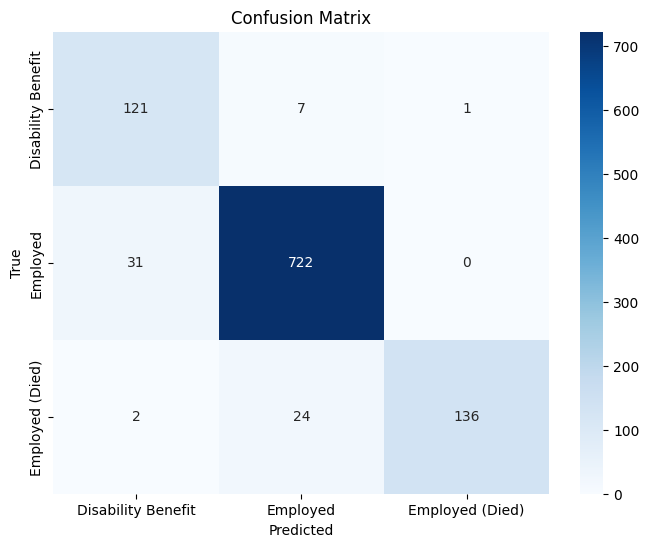


ROC AUC Score (OvR): 0.9469
ROC AUC Score (OvO): 0.9557

=== FINAL REPORT ===
Model: LSTM with 3 layers (128, 64 and 32 units)
Cross-validation: 5-fold stratified

Average Performance Across Folds:
- Balanced Accuracy: 0.9121 ± 0.0176
- Accuracy: 0.9377 ± 0.0076
- Cohen's Kappa: 0.8587 ± 0.0185
- Matthews Correlation: 0.8603 ± 0.0185
- ROC AUC (OvR): 0.9491 ± 0.0159
- ROC AUC (OvO): 0.9570 ± 0.0154

Class 0 (Disability Benefit):
- Precision: 0.7880 ± 0.0386
- Recall: 0.9378 ± 0.0311
- F1-score: 0.8553 ± 0.0188
- Accuracy: 0.9378 ± 0.0311

Class 1 (Employed):
- Precision: 0.9590 ± 0.0117
- Recall: 0.9589 ± 0.0105
- F1-score: 0.9588 ± 0.0061
- Accuracy: 0.9589 ± 0.0105

Class 2 (Employed (Died)):
- Precision: 0.9929 ± 0.0143
- Recall: 0.8396 ± 0.0353
- F1-score: 0.9093 ± 0.0214
- Accuracy: 0.8396 ± 0.0353

Confusion Matrix (All Predictions):
[[121   7   1]
 [ 31 722   0]
 [  2  24 136]]


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, balanced_accuracy_score,
                            accuracy_score, precision_recall_fscore_support,
                            confusion_matrix, roc_auc_score, cohen_kappa_score,
                            matthews_corrcoef)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from keras import backend as K

# --- Set Random Seeds for Reproducibility ---
random.seed(1927)
np.random.seed(1927)
tf.random.set_seed(1927)

# --- Data Loading and Preparation ---
data = pd.read_csv('sledatacutsdi.csv', parse_dates=['ASSDT'])
data = data[data['end_state'].isin(['Disability Benefit', 'Employed', "Employed (Died)"])]  # Three classes

# Feature Engineering
data['sdi_flare_interaction'] = data['score_n'] * data['total_flares']
data['flares_per_month'] = data['total_flares'] / (data['time_since_first']/30 + 1e-6)
data['delta_SLEDAI_Renal'] = data.groupby('PTNO')['SLEDAI_Renal'].diff().fillna(0)
data['time_between_visits'] = data.groupby('PTNO')['ASSDT'].diff().dt.days
data['visits_last_year'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.apply(lambda d: ((x >= (d - pd.Timedelta(days=365))) & (x <= d)).sum())
)

# Select features
numeric_cols = [col for col in data.select_dtypes(include=['int64', 'float64']).columns
               if col not in ['PTNO', 'total_visits96', 'time_first_last96', 'total_visits',
                             'time_first_last','AMS_alt', 'first_change_index', 'time_since_first',
                             'time_since_last', 'ID', 'MAXSTEROIDDOSE', 'time_between96',
                             'early_retirement', 'DEATH', 'age_at_death', 'age_at_retirement',
                             'EMP_numeric', 'lupus_primary_death', 'visit_num96',
                             'lupus_secondary_death', 'time_to_first_change', 'cum_time']]

# --- Data Cleaning and Scaling ---
for col in numeric_cols:
    # Handle infinite values
    data[col] = data[col].replace([np.inf, -np.inf], np.nan)

    # Log-transform large values
    if data[col].max() > 1e6:
        data[col] = np.log1p(data[col])

    # Fill NaNs
    data[col] = data[col].fillna(0)

# Apply scaling
scaler = MinMaxScaler(feature_range=(0, 1))
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
data['end_state_encoded'] = LabelEncoder().fit_transform(data['end_state'])

# --- Feature Selection with Random Forest ---
print("=== Feature Selection with Random Forest ===")

# Get MAXIMUM value for each patient
max_obs = data.groupby('PTNO')[numeric_cols].max()
y_labels = data.groupby('PTNO')['end_state_encoded'].last()  # Last outcome

# Train RF to get feature importances
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(max_obs, y_labels)

# Get top 20 features
importances = rf.feature_importances_
top_25_idx = np.argsort(importances)[-25:]
selected_features = [numeric_cols[i] for i in top_25_idx]

print("\nSelected Top 20 Features:")
for i, feat in enumerate(selected_features):
    print(f"{i+1}. {feat} (importance: {importances[top_25_idx][i]:.4f})")

# --- Prepare Sequences with Selected Features ---
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()

    X_seq = np.zeros((len(patients), max_seq_length, len(features)))
    y = np.zeros(len(patients))

    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        X_seq[i, :seq_len, :] = patient_data[features].values
        y[i] = patient_data['end_state_encoded'].iloc[-1]

    return X_seq, to_categorical(y)

# Create sequences with only selected features
X_seq, y = create_sequences(data, selected_features)
y_labels = np.argmax(y, axis=1)

# --- Class Balance Analysis ---
print("\n=== Class Distribution ===")
class_counts = Counter(y_labels)
for class_label, count in class_counts.items():
    class_name = ['Disability Benefit', 'Employed', "Employed (Died)"][class_label]
    print(f"Class {class_label} ({class_name}): {count} samples ({count/len(y_labels):.2%})")

# --- Data Augmentation for Minority Class ---
def augment_minority_class(X, y, minority_class=2, augmentation_factor=5):
    """Augment minority class samples by adding small noise to existing samples"""
    minority_indices = np.where(np.argmax(y, axis=1) == minority_class)[0]
    X_minority = X[minority_indices]
    y_minority = y[minority_indices]

    if len(X_minority) == 0:
        return X, y

    augmented_X = [X]
    augmented_y = [y]

    for _ in range(augmentation_factor):
        noise = np.random.normal(0, 0.01, size=X_minority.shape)
        augmented_X.append(X_minority + noise)
        augmented_y.append(y_minority)

    augmented_X = np.concatenate(augmented_X)
    augmented_y = np.concatenate(augmented_y)

    return augmented_X, augmented_y

# Augment only if minority class exists
if 2 in y_labels:
    X_seq_aug, y_aug = augment_minority_class(X_seq, y)
    y_labels_aug = np.argmax(y_aug, axis=1)
    print("\nAfter augmentation:")
    for class_label, count in Counter(y_labels_aug).items():
        class_name = ['Disability Benefit', 'Employed', "Employed (Died)"][class_label]
        print(f"Class {class_label} ({class_name}): {count} samples ({count/len(y_labels_aug):.2%})")
else:
    X_seq_aug, y_aug = X_seq, y
    y_labels_aug = y_labels

# Verify shapes before training
print("\n=== Data Shapes ===")
print(f"X_seq_aug shape: {X_seq_aug.shape}")  # Should be (n_samples, seq_length, n_features)
print(f"y_aug shape: {y_aug.shape}")  # Should be (n_samples, n_classes)

import tensorflow as tf
def balanced_accuracy_metric(y_true, y_pred):
    y_pred_classes = tf.argmax(y_pred, axis=-1)
    y_true_classes = tf.argmax(y_true, axis=-1)

    num_classes = y_pred.shape[1]  # Requires static shape

    class_accs = []
    for class_id in range(num_classes):
        mask = tf.equal(y_true_classes, class_id)
        class_correct = tf.reduce_sum(
            tf.cast(tf.equal(y_pred_classes[mask], y_true_classes[mask]), tf.float32)
        )
        class_total = tf.reduce_sum(tf.cast(mask, tf.float32))
        class_acc = class_correct / (class_total + tf.keras.backend.epsilon())
        class_accs.append(class_acc)

    return tf.reduce_mean(class_accs)

# --- LSTM Model with Improved Architecture ---
def build_lstm_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Masking(mask_value=0)(inputs)

    # First LSTM layer with more units
    x = LSTM(128, return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    # Second LSTM layer
    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    # Third LSTM layer
    x = LSTM(32)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Additional dense layer
    x = Dense(32, activation='relu')(x)
    x = BatchNormalization()(x)

    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)

    # Custom metrics for imbalanced data
    metrics = [
        'accuracy',
        balanced_accuracy_metric,
        tf.keras.metrics.AUC(name='auc', multi_label=True),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.F1Score(name='f1_score', average='weighted')
    ]

    model.compile(optimizer=Adam(0.001),
                loss='categorical_crossentropy',
                metrics=metrics)

    return model

# --- LSTM Training with Selected Features ---
print("\n=== Training LSTM with Selected Features ===")
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1927)

# Initialize metric storage
fold_metrics = {
    'precision_0': [], 'recall_0': [], 'f1_0': [],
    'precision_1': [], 'recall_1': [], 'f1_1': [],
    'precision_2': [], 'recall_2': [], 'f1_2': [],
    'bal_acc': [], 'acc': [], 'roc_auc_ovr': [], 'roc_auc_ovo': [],
    'kappa': [], 'mcc': []
}

class_accuracies = {0: [], 1: [], 2: []}  # To store accuracies for each class
all_y_true = []
all_y_pred = []
all_y_probs = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_seq_aug, y_labels_aug)):
    print(f"\nFold {fold + 1}/{n_splits}")

    X_train, X_val = X_seq_aug[train_idx], X_seq_aug[val_idx]
    y_train, y_val = y_aug[train_idx], y_aug[val_idx]
    y_train_labels = np.argmax(y_train, axis=1)

    # Compute class weights
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    # Build and train model
    model = build_lstm_model((X_seq_aug.shape[1], X_seq_aug.shape[2]), y_aug.shape[1])

    callbacks = [
        EarlyStopping(
            monitor='val_balanced_accuracy_metric',
            patience=20,
            restore_best_weights=True,
            min_delta=0.001,
            mode='max'
        ),
        ReduceLROnPlateau(
            monitor='val_balanced_accuracy_metric',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1,
            mode='max'
        ),
        ModelCheckpoint(
            filepath=f'best_model_fold{fold}.h5',
            monitor='val_balanced_accuracy_metric',
            save_best_only=True,
            mode='max'
        )
    ]

    # Apply class weights through sample weights
    sample_weights = np.array([class_weight_dict[label] for label in y_train_labels])

    history = model.fit(
        X_train, y_train,
        epochs=300,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
        sample_weight=sample_weights  # Using sample_weight instead of class_weight
    )

    # Load the best model
    try:
        model = load_model(f'best_model_fold{fold}.h5',
                          custom_objects={'balanced_accuracy_metric': balanced_accuracy_metric})
    except:
        print(f"Could not load best model for fold {fold+1}, using last epoch's model")

    # Evaluate
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_val, axis=1)

    # Store predictions for overall evaluation
    all_y_true.extend(y_true_classes)
    all_y_pred.extend(y_pred_classes)
    all_y_probs.extend(y_pred)

    # Calculate metrics
    bal_acc = balanced_accuracy_score(y_true_classes, y_pred_classes)
    acc = accuracy_score(y_true_classes, y_pred_classes)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true_classes, y_pred_classes, zero_division=0)
    kappa = cohen_kappa_score(y_true_classes, y_pred_classes)
    mcc = matthews_corrcoef(y_true_classes, y_pred_classes)

    # For multi-class ROC AUC
    if len(np.unique(y_true_classes)) > 2:
        try:
            roc_auc_ovr = roc_auc_score(y_true_classes, y_pred, multi_class='ovr')
            roc_auc_ovo = roc_auc_score(y_true_classes, y_pred, multi_class='ovo')
        except:
            roc_auc_ovr = np.nan
            roc_auc_ovo = np.nan

    # Store fold metrics
    for class_label in [0, 1, 2]:
        fold_metrics[f'precision_{class_label}'].append(precision[class_label] if class_label < len(precision) else np.nan)
        fold_metrics[f'recall_{class_label}'].append(recall[class_label] if class_label < len(recall) else np.nan)
        fold_metrics[f'f1_{class_label}'].append(f1[class_label] if class_label < len(f1) else np.nan)

    fold_metrics['bal_acc'].append(bal_acc)
    fold_metrics['acc'].append(acc)
    fold_metrics['kappa'].append(kappa)
    fold_metrics['mcc'].append(mcc)

    if len(np.unique(y_true_classes)) > 2:
        fold_metrics['roc_auc_ovr'].append(roc_auc_ovr)
        fold_metrics['roc_auc_ovo'].append(roc_auc_ovo)

    # Calculate and store accuracy for each class
    for class_label in [0, 1, 2]:
        class_mask = y_true_classes == class_label
        if sum(class_mask) > 0:
            class_acc = accuracy_score(y_true_classes[class_mask], y_pred_classes[class_mask])
            class_accuracies[class_label].append(class_acc)

    # Print fold results
    print(f"\nFold {fold + 1} Results:")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"Matthews Correlation: {mcc:.4f}")
    if len(np.unique(y_true_classes)) > 2:
        print(f"ROC AUC (OvR): {roc_auc_ovr:.4f}")
        print(f"ROC AUC (OvO): {roc_auc_ovo:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes,
                              target_names=['Disability Benefit', 'Employed', "Employed (Died)"],
                              zero_division=0))

    # Clean up model file
    try:
        os.remove(f'best_model_fold{fold}.h5')
    except:
        pass

# --- Final Evaluation ---
print("\n=== Final LSTM Evaluation ===")

# Calculate mean and std of all metrics
final_metrics = {k: (np.mean(v), np.std(v)) for k, v in fold_metrics.items() if len(v) > 0}

# Print averaged metrics
print("\n=== Average Performance Across All Folds ===")
print(f"Balanced Accuracy: {final_metrics['bal_acc'][0]:.4f} ± {final_metrics['bal_acc'][1]:.4f}")
print(f"Accuracy: {final_metrics['acc'][0]:.4f} ± {final_metrics['acc'][1]:.4f}")
print(f"Cohen's Kappa: {final_metrics['kappa'][0]:.4f} ± {final_metrics['kappa'][1]:.4f}")
print(f"Matthews Correlation: {final_metrics['mcc'][0]:.4f} ± {final_metrics['mcc'][1]:.4f}")
if 'roc_auc_ovr' in final_metrics:
    print(f"ROC AUC (OvR): {final_metrics['roc_auc_ovr'][0]:.4f} ± {final_metrics['roc_auc_ovr'][1]:.4f}")
    print(f"ROC AUC (OvO): {final_metrics['roc_auc_ovo'][0]:.4f} ± {final_metrics['roc_auc_ovo'][1]:.4f}")

print("\n=== Class-wise Average Performance ===")
for class_label in [0, 1, 2]:
    if len(class_accuracies.get(class_label, [])) > 0:
        print(f"\nClass {class_label}:")
        print(f"  Precision: {final_metrics[f'precision_{class_label}'][0]:.4f} ± {final_metrics[f'precision_{class_label}'][1]:.4f}")
        print(f"  Recall: {final_metrics[f'recall_{class_label}'][0]:.4f} ± {final_metrics[f'recall_{class_label}'][1]:.4f}")
        print(f"  F1-score: {final_metrics[f'f1_{class_label}'][0]:.4f} ± {final_metrics[f'f1_{class_label}'][1]:.4f}")
        print(f"  Accuracy: {np.mean(class_accuracies[class_label]):.4f} ± {np.std(class_accuracies[class_label]):.4f}")

# --- Comprehensive Evaluation on All Predictions ---
print("\n=== Comprehensive Evaluation on All Predictions ===")
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_probs = np.array(all_y_probs)

print("\nClassification Report:")
print(classification_report(all_y_true, all_y_pred,
                          target_names=['Disability Benefit', 'Employed', "Employed (Died)"],
                          zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(all_y_true, all_y_pred)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Disability Benefit', 'Employed', "Employed (Died)"],
            yticklabels=['Disability Benefit', 'Employed', "Employed (Died)"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

if len(np.unique(all_y_true)) > 2:
    try:
        print(f"\nROC AUC Score (OvR): {roc_auc_score(all_y_true, all_y_probs, multi_class='ovr'):.4f}")
        print(f"ROC AUC Score (OvO): {roc_auc_score(all_y_true, all_y_probs, multi_class='ovo'):.4f}")
    except:
        print("\nCould not calculate multi-class ROC AUC scores")

# --- Generate Final Report ---
print("\n=== FINAL REPORT ===")
print("Model: LSTM with 3 layers (128, 64 and 32 units)")
print(f"Cross-validation: {n_splits}-fold stratified")
print("\nAverage Performance Across Folds:")
print(f"- Balanced Accuracy: {final_metrics['bal_acc'][0]:.4f} ± {final_metrics['bal_acc'][1]:.4f}")
print(f"- Accuracy: {final_metrics['acc'][0]:.4f} ± {final_metrics['acc'][1]:.4f}")
print(f"- Cohen's Kappa: {final_metrics['kappa'][0]:.4f} ± {final_metrics['kappa'][1]:.4f}")
print(f"- Matthews Correlation: {final_metrics['mcc'][0]:.4f} ± {final_metrics['mcc'][1]:.4f}")
if 'roc_auc_ovr' in final_metrics:
    print(f"- ROC AUC (OvR): {final_metrics['roc_auc_ovr'][0]:.4f} ± {final_metrics['roc_auc_ovr'][1]:.4f}")
    print(f"- ROC AUC (OvO): {final_metrics['roc_auc_ovo'][0]:.4f} ± {final_metrics['roc_auc_ovo'][1]:.4f}")

for class_label in [0, 1, 2]:
    if len(class_accuracies.get(class_label, [])) > 0:
        class_name = ['Disability Benefit', 'Employed', "Employed (Died)"][class_label]
        print(f"\nClass {class_label} ({class_name}):")
        print(f"- Precision: {final_metrics[f'precision_{class_label}'][0]:.4f} ± {final_metrics[f'precision_{class_label}'][1]:.4f}")
        print(f"- Recall: {final_metrics[f'recall_{class_label}'][0]:.4f} ± {final_metrics[f'recall_{class_label}'][1]:.4f}")
        print(f"- F1-score: {final_metrics[f'f1_{class_label}'][0]:.4f} ± {final_metrics[f'f1_{class_label}'][1]:.4f}")
        print(f"- Accuracy: {np.mean(class_accuracies[class_label]):.4f} ± {np.std(class_accuracies[class_label]):.4f}")

print("\nConfusion Matrix (All Predictions):")
print(cm)

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, precision_recall_curve,
                             average_precision_score)
import matplotlib.pyplot as plt

import os
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, classification_report, roc_auc_score

# --- First, train and save the best model ---

# [Previous code remains the same until after model training]

# After cross-validation training, train a final model on all data
print("\n=== Training Final Model on All Data ===")
final_model = build_lstm_model((X_seq.shape[1], X_seq.shape[2]), y.shape[1])

# Callbacks for final training
final_callbacks = [
    EarlyStopping(
        monitor='loss',
        patience=15,
        restore_best_weights=True,
        min_delta=0.001
    ),
    ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_final_model.h5',
        monitor='accuracy',
        save_best_only=True,
        mode='max'
    )
]

# Train final model
history = final_model.fit(
    X_seq, y,
    epochs=300,
    batch_size=64,
    callbacks=final_callbacks,
    verbose=1,
    shuffle=True
)

# Load the best final model
try:
    final_model = load_model('best_final_model.h5', custom_objects=custom_objects)
    print("Successfully loaded best final model")
except Exception as e:
    print(f"Error loading final model: {e}")
    print("Using last epoch's model instead")


def assess_patient_risk_lstm_only(patient_data, model, temporal_features, max_seq_length, threshold=0.7):
    """
    Risk assessment using only LSTM model predictions
    Args:
        patient_data: DataFrame for one patient's visits
        model: Trained LSTM model
        temporal_features: List of temporal pattern features
        max_seq_length: Maximum sequence length model expects
        threshold: Risk threshold for flagging
    Returns:
        DataFrame with risk assessments for each visit
    """
    risks = []
    patient_data = patient_data.sort_values('ASSDT')

    for i in range(1, len(patient_data)+1):
        current_visit = patient_data.iloc[:i]
        current_row = current_visit.iloc[-1]

        # Prepare sequence data
        seq_len = len(current_visit)
        seq_data = np.zeros((1, max_seq_length, len(temporal_features)))
        seq_data[0, :seq_len, :] = current_visit[temporal_features].values

        # Get prediction
        pred_proba = model.predict(seq_data, verbose=0)[0][0]

        risks.append({
            'visit_date': current_row['ASSDT'],
            'visit_number': i,
            'risk_score': pred_proba,
            'flagged': pred_proba >= threshold
        })

    return pd.DataFrame(risks)

def evaluate_patients(data, model, temporal_features, max_seq_length):
    """
    Evaluate all patients using LSTM-only approach
    Args:
        data: Full dataset with all patients
        model: Trained LSTM model
        temporal_features: List of temporal features
        max_seq_length: Maximum sequence length
    Returns:
        results_df: DataFrame with evaluation results
        timing_data: List of detection times
    """
    results = []
    timing_analysis = []

    for ptno, patient_data in data.groupby('PTNO'):
        patient_data = patient_data.sort_values('ASSDT')
        final_outcome = patient_data['end_state_encoded'].iloc[-1]

        # Get risk assessment
        risk_df = assess_patient_risk_lstm_only(
            patient_data,
            model,
            temporal_features,
            max_seq_length
        )

        # Record first time flagged (if any)
        first_flag = risk_df[risk_df['flagged']]['visit_date'].min()

        # For patients who became disabled
        if final_outcome == 0:  # Disability
            if pd.notna(first_flag):
                months_before = (patient_data['ASSDT'].iloc[-1] - first_flag).days / 30
                timing_analysis.append(months_before)
            else:
                disability_date = patient_data['ASSDT'].iloc[-1]
                last_visit_date = patient_data['ASSDT'].iloc[-2] if len(patient_data) > 1 else disability_date
                months_after = (first_flag - disability_date).days / 30 if pd.notna(first_flag) else (disability_date - last_visit_date).days / 30
                timing_analysis.append(-months_after)

        # Store results
        results.append({
            'PTNO': ptno,
            'final_outcome': final_outcome,
            'ever_flagged': any(risk_df['flagged']),
            'first_flag_date': first_flag,
            'max_risk_score': risk_df['risk_score'].max(),
            'final_risk_score': risk_df['risk_score'].iloc[-1],
            'num_visits': len(patient_data)
        })

    return pd.DataFrame(results)



# Example Usage
if __name__ == "__main__":
    # Assuming you have these defined:
    # data = your patient data
    # final_model = your trained LSTM model
    # selected_features = your temporal features
    # X_seq = your sequence data (for getting max_seq_length)

    max_seq_length = X_seq.shape[1]  # Get sequence length from training data

    results_df = evaluate_patients(
        data,
        final_model,
        temporal_features=selected_features,
        max_seq_length=max_seq_length
    )




=== Training Final Model on All Data ===
Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.3639 - auc: 0.5827 - balanced_accuracy_metric: 0.4182 - f1_score: 0.4496 - loss: 1.8176 - precision: 0.3479 - recall: 0.2653

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.3675 - auc: 0.5878 - balanced_accuracy_metric: 0.4214 - f1_score: 0.4534 - loss: 1.8076 - precision: 0.3525 - recall: 0.2682 - learning_rate: 0.0010
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.5478 - auc: 0.7396 - balanced_accuracy_metric: 0.5619 - f1_score: 0.6339 - loss: 1.4066 - precision: 0.5821 - recall: 0.4042

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.5492 - auc: 0.7410 - balanced_accuracy_metric: 0.5633 - f1_score: 0.6350 - loss: 1.4016 - precision: 0.5845 - recall: 0.4052 - learning_rate: 0.0010
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.6941 - auc: 0.7958 - balanced_accuracy_metric: 0.6018 - f1_score: 0.7536 - loss: 1.1559 - precision: 0.7588 - recall: 0.5053

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.6954 - auc: 0.7952 - balanced_accuracy_metric: 0.6008 - f1_score: 0.7547 - loss: 1.1519 - precision: 0.7600 - recall: 0.5068 - learning_rate: 0.0010
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8000 - auc: 0.8173 - balanced_accuracy_metric: 0.6365 - f1_score: 0.8304 - loss: 1.0502 - precision: 0.8578 - recall: 0.6141

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - accuracy: 0.8004 - auc: 0.8163 - balanced_accuracy_metric: 0.6356 - f1_score: 0.8307 - loss: 1.0450 - precision: 0.8579 - recall: 0.6156 - learning_rate: 0.0010
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8281 - auc: 0.7836 - balanced_accuracy_metric: 0.5591 - f1_score: 0.8480 - loss: 0.9245 - precision: 0.8638 - recall: 0.7174

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.9654 - auc: 0.9718 - balanced_accuracy_metric: 0.7784 - f1_score: 0.9615 - loss: 0.1439 - precision: 0.9653 - recall: 0.9644 - learning_rate: 5.0000e-04
Epoch 103/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.9654 - auc: 0.9721 - balanced_accuracy_metric: 0.7677 - f1_score: 0.9599 - loss: 0.1414 - precision: 0.9682 - recall: 0.9654 - learning_rate: 5.0000e-04
Epoch 104/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.9599 - auc: 0.9740 - balanced_accuracy_metric: 0.7274 - f1_score: 0.9538 - loss: 0.1437 - precision: 0.9607 - recall: 0.9597 - learning_rate: 5.0000e-04
Epoch 105/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.9643 - auc: 0.9746 - balanced_accuracy_metric: 0.7616 - f1_score: 0.9609 - loss: 0.1429 - precision: 0.9671 - recall: 0.9625 - learning_rate: 5.0000e-04
Epoch 106/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.9651 - auc: 0.9677 - balanced_accuracy_metric: 0.7908 - f

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.9697 - auc: 0.9825 - balanced_accuracy_metric: 0.8070 - f1_score: 0.9667 - loss: 0.1320 - precision: 0.9707 - recall: 0.9690 - learning_rate: 5.0000e-04
Epoch 115/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.9692 - auc: 0.9771 - balanced_accuracy_metric: 0.8023 - f1_score: 0.9654 - loss: 0.1566 - precision: 0.9697 - recall: 0.9663 - learning_rate: 5.0000e-04
Epoch 116/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - accuracy: 0.9689 - auc: 0.9618 - balanced_accuracy_metric: 0.7770 - f1_score: 0.9651 - loss: 0.1455 - precision: 0.9689 - recall: 0.9689 - learning_rate: 5.0000e-04
Epoch 117/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.9570 - auc: 0.9715 - balanced_accuracy_metric: 0.7529 - f1_score: 0.9537 - loss: 0.1549 - precision: 0.9568 - recall: 0.9541 - learning_rate: 5.0000e-04
Epoch 118/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9736 - auc: 0.9755 - balanced_accuracy_metric: 0.7887 - f

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.9735 - auc: 0.9756 - balanced_accuracy_metric: 0.7871 - f1_score: 0.9705 - loss: 0.1314 - precision: 0.9752 - recall: 0.9735 - learning_rate: 5.0000e-04
Epoch 119/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - accuracy: 0.9626 - auc: 0.9867 - balanced_accuracy_metric: 0.7801 - f1_score: 0.9589 - loss: 0.1384 - precision: 0.9647 - recall: 0.9624 - learning_rate: 5.0000e-04
Epoch 120/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 211ms/step - accuracy: 0.9436 - auc: 0.9344 - balanced_accuracy_metric: 0.7062 - f1_score: 0.9379 - loss: 0.2062 - precision: 0.9440 - recall: 0.9420 - learning_rate: 5.0000e-04
Epoch 121/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 0.9586 - auc: 0.9643 - balanced_accuracy_metric: 0.7216 - f1_score: 0.9543 - loss: 0.1659 - precision: 0.9593 - recall: 0.9586 - learning_rate: 5.0000e-04
Epoch 122/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - accuracy: 0.9550 - auc: 0.9719 - balanced_accuracy_metric: 0.7979 - f

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/step - accuracy: 0.9763 - auc: 0.9779 - balanced_accuracy_metric: 0.8078 - f1_score: 0.9734 - loss: 0.1196 - precision: 0.9762 - recall: 0.9747 - learning_rate: 2.5000e-04
Epoch 136/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 0.9660 - auc: 0.9835 - balanced_accuracy_metric: 0.8060 - f1_score: 0.9639 - loss: 0.1309 - precision: 0.9667 - recall: 0.9658 - learning_rate: 2.5000e-04
Epoch 137/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.9690 - auc: 0.9832 - balanced_accuracy_metric: 0.8092 - f1_score: 0.9660 - loss: 0.1250 - precision: 0.9690 - recall: 0.9690 - learning_rate: 2.5000e-04
Epoch 138/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 256ms/step - accuracy: 0.9701 - auc: 0.9842 - balanced_accuracy_metric: 0.7577 - f1_score: 0.9661 - loss: 0.1215 - precision: 0.9701 - recall: 0.9697 - learning_rate: 2.5000e-04
Epoch 139/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.9703 - auc: 0.9851 - balanced_accuracy_metric: 0.7412 - f

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.9766 - auc: 0.9789 - balanced_accuracy_metric: 0.8340 - f1_score: 0.9745 - loss: 0.1132 - precision: 0.9773 - recall: 0.9760 - learning_rate: 2.5000e-04
Epoch 144/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - accuracy: 0.9672 - auc: 0.9836 - balanced_accuracy_metric: 0.7465 - f1_score: 0.9628 - loss: 0.1255 - precision: 0.9688 - recall: 0.9636 - learning_rate: 2.5000e-04
Epoch 145/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - accuracy: 0.9694 - auc: 0.9822 - balanced_accuracy_metric: 0.8139 - f1_score: 0.9667 - loss: 0.1239 - precision: 0.9708 - recall: 0.9694 - learning_rate: 2.5000e-04
Epoch 146/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.9700 - auc: 0.9777 - balanced_accuracy_metric: 0.8280 - f1_score: 0.9683 - loss: 0.1265 - precision: 0.9714 - recall: 0.9681 - learning_rate: 2.5000e-04
Epoch 147/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.9742 - auc: 0.9851 - balanced_accuracy_metric: 0.8140 - f


=== Disability Early Detection Performance ===
Using threshold: 0.8448
Early warning threshold: 0.5913

Average detection time (months): 50.1
Median detection time: 31.7
Detection rate: 111/129 (86.0%)

=== Disability Alert-Level Performance ===
Confusion Matrix:
[[764  16]
 [ 12 117]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       780
           1       0.88      0.91      0.89       129

    accuracy                           0.97       909
   macro avg       0.93      0.94      0.94       909
weighted avg       0.97      0.97      0.97       909


=== Disability Warning-Level Performance ===
Confusion Matrix:
[[761  19]
 [ 10 119]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       780
           1       0.86      0.92      0.89       129

    accuracy                           0.97       909
   macro avg       0.92      0.9

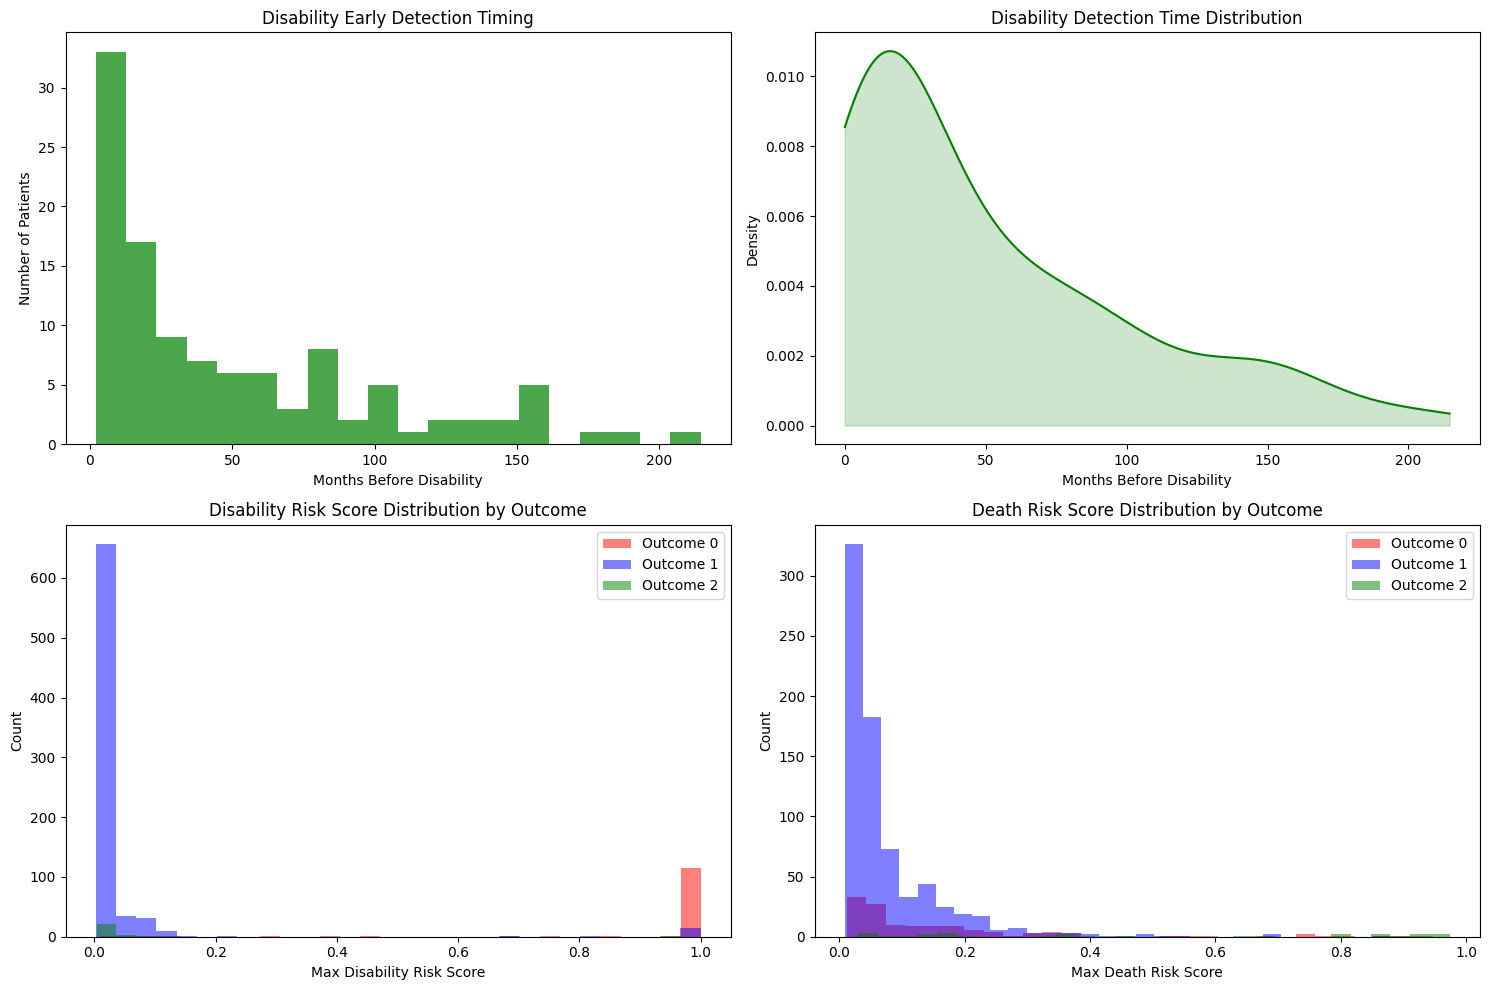

In [3]:
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, classification_report,
                           roc_auc_score, precision_recall_curve,
                           average_precision_score, roc_curve)
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def find_early_detection_threshold(y_true, y_scores, timing_data=None, min_sensitivity=0.9):
    """
    Find threshold that optimizes for early detection while maintaining sensitivity
    Args:
        y_true: True labels
        y_scores: Predicted probabilities
        timing_data: List of detection times (negative for missed cases)
        min_sensitivity: Minimum sensitivity to maintain
    Returns:
        optimal_threshold: Threshold that maximizes early detection
        detection_stats: Dictionary with detection statistics
    """
    # Calculate ROC curve metrics
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    # Filter thresholds that meet minimum sensitivity
    valid_idx = np.where(tpr >= min_sensitivity)[0]
    if len(valid_idx) == 0:
        return 0.5, {}  # Fallback if no threshold meets sensitivity

    # Get subset of thresholds that meet sensitivity
    valid_thresholds = thresholds[valid_idx]
    valid_tpr = tpr[valid_idx]

    # If no timing data, just return the threshold with highest sensitivity
    if timing_data is None:
        best_idx = np.argmax(valid_tpr)
        optimal_threshold = valid_thresholds[best_idx]
        return optimal_threshold, {}

    # For each candidate threshold, calculate detection timing
    detection_stats = []
    for thresh in valid_thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        detected_times = [t for t in timing_data if t > 0]
        avg_detection_time = np.mean(detected_times) if detected_times else 0
        detection_rate = len(detected_times) / sum(y_true)

        detection_stats.append({
            'threshold': thresh,
            'sensitivity': valid_tpr[np.where(valid_thresholds == thresh)[0][0]],
            'avg_detection_time': avg_detection_time,
            'detection_rate': detection_rate
        })

    # Select threshold with best (earliest) average detection time
    detection_stats = pd.DataFrame(detection_stats)
    best_idx = detection_stats['avg_detection_time'].idxmax()
    optimal_threshold = detection_stats.loc[best_idx, 'threshold']

    return optimal_threshold, detection_stats

def assess_patient_risk_with_early_warning(patient_data, model, temporal_features,
                                         max_seq_length, disability_threshold=0.15,
                                         death_threshold=0.15, early_warning_factor=0.7):
    """
    Enhanced risk assessment with separate early warning signals for disability and death
    Args:
        patient_data: DataFrame for one patient's visits
        model: Trained LSTM model
        temporal_features: List of temporal features
        max_seq_length: Maximum sequence length
        disability_threshold: Main risk threshold for disability
        death_threshold: Main risk threshold for death
        early_warning_factor: Fraction of main threshold for early warning
    Returns:
        DataFrame with risk assessments and warning flags for both outcomes
    """
    risks = []
    patient_data = patient_data.sort_values('ASSDT')
    disability_warning_threshold = disability_threshold * early_warning_factor
    death_warning_threshold = death_threshold * early_warning_factor

    for i in range(1, len(patient_data)+1):
        current_visit = patient_data.iloc[:i]
        current_row = current_visit.iloc[-1]

        # Prepare sequence data
        seq_len = len(current_visit)
        seq_data = np.zeros((1, max_seq_length, len(temporal_features)))
        seq_data[0, :seq_len, :] = current_visit[temporal_features].values

        # Get prediction probabilities for all classes
        pred_probas = model.predict(seq_data, verbose=0)[0]

        # Class 0 is disability, class 2 is death (assuming your encoding)
        disability_prob = pred_probas[0]
        death_prob = pred_probas[2]

        risks.append({
            'visit_date': current_row['ASSDT'],
            'visit_number': i,
            'disability_risk': disability_prob,
            'death_risk': death_prob,
            'disability_flagged': disability_prob >= disability_threshold,
            'death_flagged': death_prob >= death_threshold,
            'disability_warning': disability_prob >= disability_warning_threshold,
            'death_warning': death_prob >= death_warning_threshold
        })

    return pd.DataFrame(risks)

def evaluate_patients_with_early_detection(data, model, temporal_features,
                                         max_seq_length, timing_data=None):
    """
    Enhanced evaluation with separate tracking for disability and death outcomes
    Args:
        data: Full dataset
        model: Trained model
        temporal_features: List of temporal features
        max_seq_length: Maximum sequence length
        timing_data: Optional existing timing data (dict with 'disability' and 'death' keys)
    Returns:
        results_df: Evaluation results
        timing_data: Detection timing (dict with both outcomes)
        thresholds: Dictionary with optimal thresholds
        detection_stats: Dictionary with detection statistics
    """
    results = []
    timing_analysis = {
        'disability': [],
        'death': []
    }
    all_scores = {
        'disability': [],
        'death': []
    }
    all_outcomes = {
        'disability': [],
        'death': []
    }

    # First pass to collect all scores and outcomes
    for ptno, patient_data in data.groupby('PTNO'):
        patient_data = patient_data.sort_values('ASSDT')
        final_outcome = patient_data['end_state_encoded'].iloc[-1]

        # Get risk assessment
        risk_df = assess_patient_risk_with_early_warning(
            patient_data,
            model,
            temporal_features,
            max_seq_length,
            disability_threshold=0.5,  # Temporary thresholds
            death_threshold=0.5
        )

        # Store max scores and outcomes for both conditions
        all_scores['disability'].append(risk_df['disability_risk'].max())
        all_scores['death'].append(risk_df['death_risk'].max())

        all_outcomes['disability'].append(final_outcome == 0)  # Disability
        all_outcomes['death'].append(final_outcome == 2)      # Death

    # Find optimal thresholds for both outcomes
    thresholds = {}
    detection_stats = {}

    # For disability
    y_true_disability = np.array(all_outcomes['disability']).astype(int)
    y_scores_disability = np.array(all_scores['disability'])

    # Get timing data if not provided
    if timing_data is None or 'disability' not in timing_data:
        disability_timing = []
        for ptno, patient_data in data.groupby('PTNO'):
            patient_data = patient_data.sort_values('ASSDT')
            final_outcome = patient_data['end_state_encoded'].iloc[-1]

            if final_outcome == 0:  # Disability cases only
                risk_df = assess_patient_risk_with_early_warning(
                    patient_data,
                    model,
                    temporal_features,
                    max_seq_length
                )

                first_flag = risk_df[risk_df['disability_flagged']]['visit_date'].min()
                if pd.notna(first_flag):
                    months_before = (patient_data['ASSDT'].iloc[-1] - first_flag).days / 30
                    disability_timing.append(months_before)
                else:
                    disability_date = patient_data['ASSDT'].iloc[-1]
                    last_visit_date = patient_data['ASSDT'].iloc[-2] if len(patient_data) > 1 else disability_date
                    months_after = (disability_date - last_visit_date).days / 30
                    disability_timing.append(-months_after)
        timing_analysis['disability'] = disability_timing
    else:
        timing_analysis['disability'] = timing_data['disability']

    # Find optimal threshold for disability
    thresholds['disability'], detection_stats['disability'] = find_early_detection_threshold(
        y_true_disability, y_scores_disability, timing_analysis['disability']
    )

    # For death - typically we don't have timing data for death (can't detect after event)
    y_true_death = np.array(all_outcomes['death']).astype(int)
    y_scores_death = np.array(all_scores['death'])

    # Find threshold that maximizes sensitivity for death
    thresholds['death'], detection_stats['death'] = find_early_detection_threshold(
        y_true_death, y_scores_death, min_sensitivity=0.9
    )

    # Second pass with optimal thresholds and early warning
    for ptno, patient_data in data.groupby('PTNO'):
        patient_data = patient_data.sort_values('ASSDT')
        final_outcome = patient_data['end_state_encoded'].iloc[-1]

        # Get risk assessment with early warning
        risk_df = assess_patient_risk_with_early_warning(
            patient_data,
            model,
            temporal_features,
            max_seq_length,
            disability_threshold=thresholds['disability'],
            death_threshold=thresholds['death']
        )

        # Record first time flagged (if any) for both outcomes
        first_disability_flag = risk_df[risk_df['disability_flagged']]['visit_date'].min()
        first_death_flag = risk_df[risk_df['death_flagged']]['visit_date'].min()

        first_disability_warning = risk_df[risk_df['disability_warning']]['visit_date'].min()
        first_death_warning = risk_df[risk_df['death_warning']]['visit_date'].min()

        # Store results
        results.append({
            'PTNO': ptno,
            'final_outcome': final_outcome,
            'ever_disability_flagged': any(risk_df['disability_flagged']),
            'ever_death_flagged': any(risk_df['death_flagged']),
            'ever_disability_warned': any(risk_df['disability_warning']),
            'ever_death_warned': any(risk_df['death_warning']),
            'first_disability_flag_date': first_disability_flag,
            'first_death_flag_date': first_death_flag,
            'first_disability_warning_date': first_disability_warning,
            'first_death_warning_date': first_death_warning,
            'max_disability_risk': risk_df['disability_risk'].max(),
            'max_death_risk': risk_df['death_risk'].max(),
            'final_disability_risk': risk_df['disability_risk'].iloc[-1],
            'final_death_risk': risk_df['death_risk'].iloc[-1],
            'num_visits': len(patient_data)
        })

    return pd.DataFrame(results), timing_analysis, thresholds, detection_stats

def analyze_early_detection_results(results_df, timing_data, thresholds, detection_stats):
    """
    Enhanced analysis with separate metrics for disability and death outcomes
    """
    # Disability analysis
    disability_true = (results_df['final_outcome'] == 0).astype(int)
    disability_pred_alert = results_df['ever_disability_flagged'].astype(int)
    disability_pred_warning = results_df['ever_disability_warned'].astype(int)
    disability_scores = results_df['max_disability_risk']

    # Death analysis
    death_true = (results_df['final_outcome'] == 2).astype(int)
    death_pred_alert = results_df['ever_death_flagged'].astype(int)
    death_pred_warning = results_df['ever_death_warned'].astype(int)
    death_scores = results_df['max_death_risk']

    # Convert timing data to arrays
    disability_timing = np.array(timing_data['disability'])
    disability_detections = disability_timing[disability_timing > 0]

    print("\n=== Disability Early Detection Performance ===")
    print(f"Using threshold: {thresholds['disability']:.4f}")
    print(f"Early warning threshold: {thresholds['disability']*0.7:.4f}")

    if len(disability_detections) > 0:
        print(f"\nAverage detection time (months): {np.mean(disability_detections):.1f}")
        print(f"Median detection time: {np.median(disability_detections):.1f}")
        print(f"Detection rate: {len(disability_detections)}/{sum(disability_true)} ({len(disability_detections)/sum(disability_true):.1%})")
    else:
        print("\nNo positive detections for disability")

    print("\n=== Disability Alert-Level Performance ===")
    print("Confusion Matrix:")
    print(confusion_matrix(disability_true, disability_pred_alert))
    print("\nClassification Report:")
    print(classification_report(disability_true, disability_pred_alert))

    print("\n=== Disability Warning-Level Performance ===")
    print("Confusion Matrix:")
    print(confusion_matrix(disability_true, disability_pred_warning))
    print("\nClassification Report:")
    print(classification_report(disability_true, disability_pred_warning))

    print(f"\nROC AUC: {roc_auc_score(disability_true, disability_scores):.4f}")
    print(f"Average Precision: {average_precision_score(disability_true, disability_scores):.4f}")

    # Death analysis
    print("\n=== Death Detection Performance ===")
    print(f"Using threshold: {thresholds['death']:.4f}")
    print(f"Early warning threshold: {thresholds['death']*0.7:.4f}")

    print("\n=== Death Alert-Level Performance ===")
    print("Confusion Matrix:")
    print(confusion_matrix(death_true, death_pred_alert))
    print("\nClassification Report:")
    print(classification_report(death_true, death_pred_alert))

    print("\n=== Death Warning-Level Performance ===")
    print("Confusion Matrix:")
    print(confusion_matrix(death_true, death_pred_warning))
    print("\nClassification Report:")
    print(classification_report(death_true, death_pred_warning))

    print(f"\nROC AUC: {roc_auc_score(death_true, death_scores):.4f}")
    print(f"Average Precision: {average_precision_score(death_true, death_scores):.4f}")

    # Plotting
    plt.figure(figsize=(15, 10))

    # Disability detection time distribution
    if len(disability_detections) > 0:
        plt.subplot(2, 2, 1)
        plt.hist(disability_detections, bins=20, color='green', alpha=0.7)
        plt.xlabel('Months Before Disability')
        plt.ylabel('Number of Patients')
        plt.title('Disability Early Detection Timing')

        plt.subplot(2, 2, 2)
        density = gaussian_kde(disability_detections)
        xs = np.linspace(0, max(disability_detections), 200)
        plt.plot(xs, density(xs), color='green')
        plt.fill_between(xs, density(xs), color='green', alpha=0.2)
        plt.xlabel('Months Before Disability')
        plt.ylabel('Density')
        plt.title('Disability Detection Time Distribution')

    # Risk score distributions
    plt.subplot(2, 2, 3)
    for outcome, color in zip([0, 1, 2], ['red', 'blue', 'green']):
        subset = results_df[results_df['final_outcome'] == outcome]
        plt.hist(subset['max_disability_risk'], bins=30, alpha=0.5, color=color,
                label=f'Outcome {outcome}')
    plt.xlabel('Max Disability Risk Score')
    plt.ylabel('Count')
    plt.title('Disability Risk Score Distribution by Outcome')
    plt.legend()

    plt.subplot(2, 2, 4)
    for outcome, color in zip([0, 1, 2], ['red', 'blue', 'green']):
        subset = results_df[results_df['final_outcome'] == outcome]
        plt.hist(subset['max_death_risk'], bins=30, alpha=0.5, color=color,
                label=f'Outcome {outcome}')
    plt.xlabel('Max Death Risk Score')
    plt.ylabel('Count')
    plt.title('Death Risk Score Distribution by Outcome')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Example Usage
if __name__ == "__main__":
    # Assuming you have these defined:
    # data = your patient data
    # final_model = your trained LSTM model
    # selected_features = your temporal features
    # X_seq = your sequence data (for getting max_seq_length)

    max_seq_length = X_seq.shape[1]

    # Run evaluation with early detection focus
    results_df, timing_data, thresholds, det_stats = evaluate_patients_with_early_detection(
        data,
        final_model,
        temporal_features=selected_features,
        max_seq_length=max_seq_length
    )

    # Analyze results
    analyze_early_detection_results(results_df, timing_data, thresholds, det_stats)

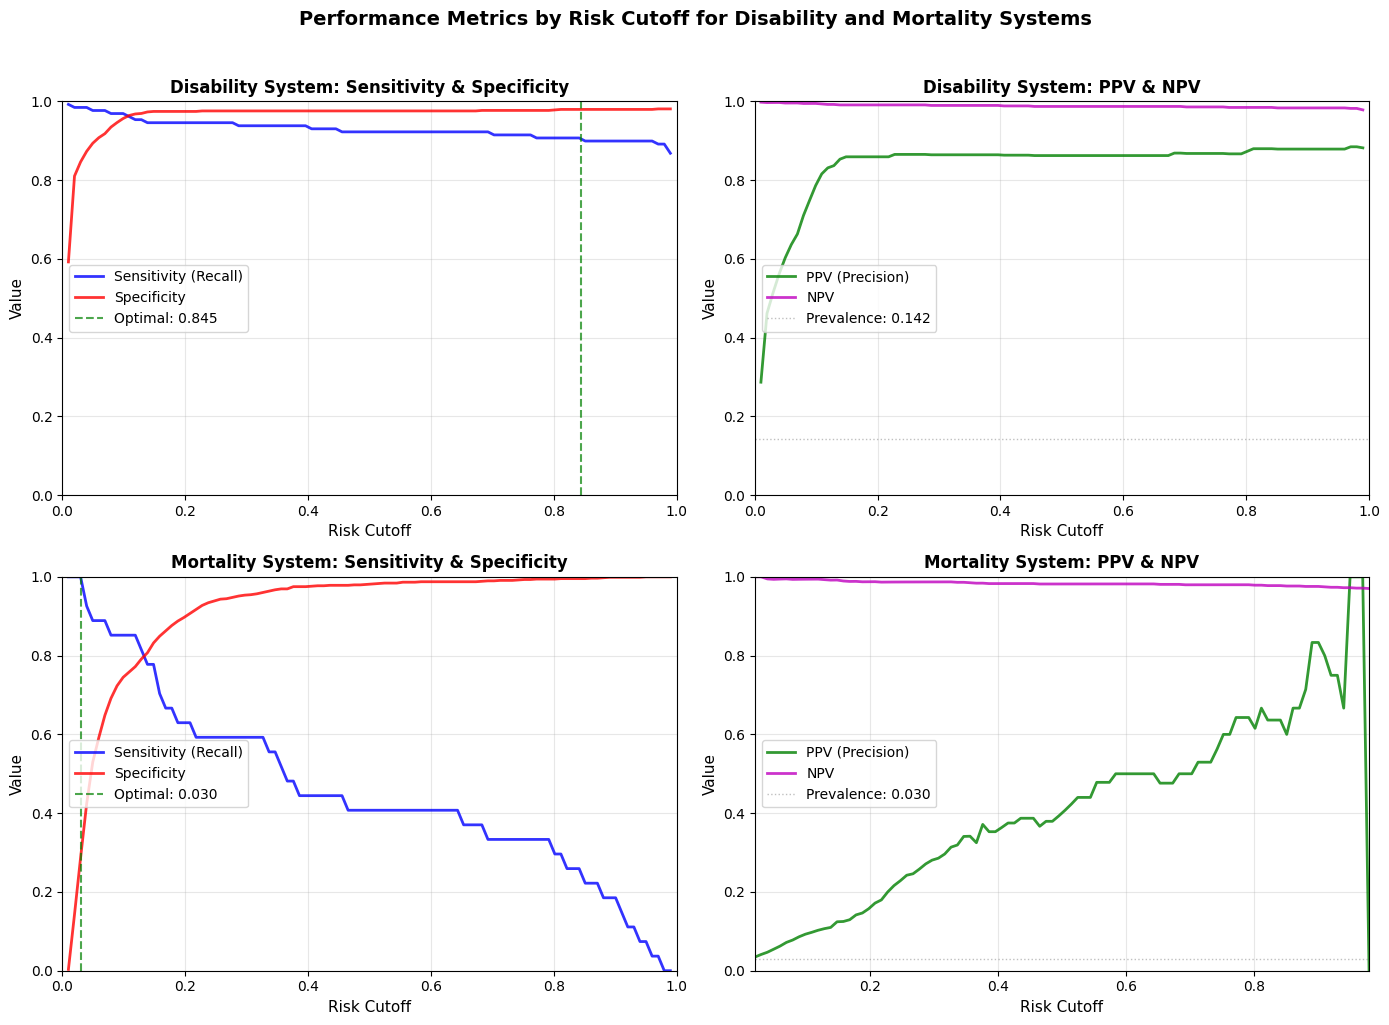

In [4]:
def plot_metrics_by_cutoff(results_df):
    """
    Plot metrics by cutoff for both disability and mortality systems.
    Top row: Disability system
    Bottom row: Mortality system
    Left column: Sensitivity and Specificity
    Right column: PPV and NPV
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import confusion_matrix

    # Prepare data for both systems
    disability_true = (results_df['final_outcome'] == 0).astype(int)
    death_true = (results_df['final_outcome'] == 2).astype(int)

    disability_scores = results_df['max_disability_risk']
    death_scores = results_df['max_death_risk']

    # Define cutoff range
    cutoffs = np.linspace(0.01, 0.99, 100)

    # Calculate metrics for each cutoff
    disability_metrics = []
    death_metrics = []

    for cutoff in cutoffs:
        # Disability metrics
        disability_pred = (disability_scores >= cutoff).astype(int)
        tn, fp, fn, tp = confusion_matrix(disability_true, disability_pred).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0

        disability_metrics.append({
            'cutoff': cutoff,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'ppv': ppv,
            'npv': npv
        })

        # Death metrics
        death_pred = (death_scores >= cutoff).astype(int)
        tn, fp, fn, tp = confusion_matrix(death_true, death_pred).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0

        death_metrics.append({
            'cutoff': cutoff,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'ppv': ppv,
            'npv': npv
        })

    # Convert to DataFrames
    disability_metrics = pd.DataFrame(disability_metrics)
    death_metrics = pd.DataFrame(death_metrics)

    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Disability System - Sensitivity & Specificity
    ax1 = axes[0, 0]
    ax1.plot(disability_metrics['cutoff'], disability_metrics['sensitivity'],
             'b-', linewidth=2, label='Sensitivity')
    ax1.plot(disability_metrics['cutoff'], disability_metrics['specificity'],
             'r-', linewidth=2, label='Specificity')
    ax1.set_xlabel('Risk Cutoff')
    ax1.set_ylabel('Value')
    ax1.set_title('Disability System: Sensitivity & Specificity vs. Cutoff')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])

    # Find optimal cutoff (Youden's J statistic)
    youden_j = disability_metrics['sensitivity'] + disability_metrics['specificity'] - 1
    optimal_idx = youden_j.idxmax()
    optimal_cutoff = disability_metrics.loc[optimal_idx, 'cutoff']
    optimal_sens = disability_metrics.loc[optimal_idx, 'sensitivity']
    optimal_spec = disability_metrics.loc[optimal_idx, 'specificity']

    ax1.axvline(x=optimal_cutoff, color='gray', linestyle='--', alpha=0.7)
    ax1.annotate(f'Optimal: {optimal_cutoff:.2f}\nSens: {optimal_sens:.2f}, Spec: {optimal_spec:.2f}',
                xy=(optimal_cutoff, 0.5), xytext=(0.05, 0.3),
                arrowprops=dict(arrowstyle='->', color='gray'))

    # Disability System - PPV & NPV
    ax2 = axes[0, 1]
    ax2.plot(disability_metrics['cutoff'], disability_metrics['ppv'],
             'g-', linewidth=2, label='PPV (Precision)')
    ax2.plot(disability_metrics['cutoff'], disability_metrics['npv'],
             'm-', linewidth=2, label='NPV')
    ax2.set_xlabel('Risk Cutoff')
    ax2.set_ylabel('Value')
    ax2.set_title('Disability System: PPV & NPV vs. Cutoff')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1])

    # Add prevalence line for PPV context
    prevalence = disability_true.mean()
    ax2.axhline(y=prevalence, color='gray', linestyle=':', alpha=0.5,
               label=f'Prevalence: {prevalence:.2f}')
    ax2.legend(loc='best')

    # Mortality System - Sensitivity & Specificity
    ax3 = axes[1, 0]
    ax3.plot(death_metrics['cutoff'], death_metrics['sensitivity'],
             'b-', linewidth=2, label='Sensitivity')
    ax3.plot(death_metrics['cutoff'], death_metrics['specificity'],
             'r-', linewidth=2, label='Specificity')
    ax3.set_xlabel('Risk Cutoff')
    ax3.set_ylabel('Value')
    ax3.set_title('Mortality System: Sensitivity & Specificity vs. Cutoff')
    ax3.legend(loc='best')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim([0, 1])
    ax3.set_ylim([0, 1])

    # Find optimal cutoff for mortality
    youden_j = death_metrics['sensitivity'] + death_metrics['specificity'] - 1
    optimal_idx = youden_j.idxmax()
    optimal_cutoff = death_metrics.loc[optimal_idx, 'cutoff']
    optimal_sens = death_metrics.loc[optimal_idx, 'sensitivity']
    optimal_spec = death_metrics.loc[optimal_idx, 'specificity']

    ax3.axvline(x=optimal_cutoff, color='gray', linestyle='--', alpha=0.7)
    ax3.annotate(f'Optimal: {optimal_cutoff:.2f}\nSens: {optimal_sens:.2f}, Spec: {optimal_spec:.2f}',
                xy=(optimal_cutoff, 0.5), xytext=(0.05, 0.3),
                arrowprops=dict(arrowstyle='->', color='gray'))

    # Mortality System - PPV & NPV
    ax4 = axes[1, 1]
    ax4.plot(death_metrics['cutoff'], death_metrics['ppv'],
             'g-', linewidth=2, label='PPV (Precision)')
    ax4.plot(death_metrics['cutoff'], death_metrics['npv'],
             'm-', linewidth=2, label='NPV')
    ax4.set_xlabel('Risk Cutoff')
    ax4.set_ylabel('Value')
    ax4.set_title('Mortality System: PPV & NPV vs. Cutoff')
    ax4.legend(loc='best')
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([0, 1])
    ax4.set_ylim([0, 1])

    # Add prevalence line for PPV context
    prevalence = death_true.mean()
    ax4.axhline(y=prevalence, color='gray', linestyle=':', alpha=0.5,
               label=f'Prevalence: {prevalence:.2f}')
    ax4.legend(loc='best')

    plt.tight_layout()
    return fig, axes, disability_metrics, death_metrics

def plot_comprehensive_metrics(results_df, thresholds=None):
    """
    Comprehensive plotting with all metrics for both systems
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Prepare data
    disability_true = (results_df['final_outcome'] == 0).astype(int)
    death_true = (results_df['final_outcome'] == 2).astype(int)

    disability_scores = results_df['max_disability_risk']
    death_scores = results_df['max_death_risk']

    # Define cutoff range
    cutoffs = np.linspace(0.01, 0.99, 100)

    # Calculate all metrics
    metrics_disability = []
    metrics_death = []

    for cutoff in cutoffs:
        # Disability
        pred = (disability_scores >= cutoff).astype(int)
        tn, fp, fn, tp = confusion_matrix(disability_true, pred).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0

        metrics_disability.append({
            'cutoff': cutoff,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'ppv': ppv,
            'npv': npv,
            'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0,
            'fnr': fn / (fn + tp) if (fn + tp) > 0 else 0
        })

        # Death
        pred = (death_scores >= cutoff).astype(int)
        tn, fp, fn, tp = confusion_matrix(death_true, pred).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0

        metrics_death.append({
            'cutoff': cutoff,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'ppv': ppv,
            'npv': npv,
            'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0,
            'fnr': fn / (fn + tp) if (fn + tp) > 0 else 0
        })

    metrics_disability = pd.DataFrame(metrics_disability)
    metrics_death = pd.DataFrame(metrics_death)

    # Plot 1: Disability - Sensitivity & Specificity
    ax1 = axes[0, 0]
    ax1.plot(metrics_disability['cutoff'], metrics_disability['sensitivity'],
             'b-', linewidth=2, label='Sensitivity (Recall)', alpha=0.8)
    ax1.plot(metrics_disability['cutoff'], metrics_disability['specificity'],
             'r-', linewidth=2, label='Specificity', alpha=0.8)
    ax1.set_xlabel('Risk Cutoff', fontsize=11)
    ax1.set_ylabel('Value', fontsize=11)
    ax1.set_title('Disability System: Sensitivity & Specificity', fontsize=12, fontweight='bold')
    ax1.legend(loc='center left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])

    # Add threshold line if provided
    if thresholds and 'disability' in thresholds:
        ax1.axvline(x=thresholds['disability'], color='green', linestyle='--',
                   linewidth=1.5, alpha=0.7, label=f'Optimal: {thresholds["disability"]:.3f}')
        ax1.legend(loc='center left', fontsize=10)

    # Plot 2: Disability - PPV & NPV
    ax2 = axes[0, 1]
    ax2.plot(metrics_disability['cutoff'], metrics_disability['ppv'],
             'g-', linewidth=2, label='PPV (Precision)', alpha=0.8)
    ax2.plot(metrics_disability['cutoff'], metrics_disability['npv'],
             'm-', linewidth=2, label='NPV', alpha=0.8)
    ax2.set_xlabel('Risk Cutoff', fontsize=11)
    ax2.set_ylabel('Value', fontsize=11)
    ax2.set_title('Disability System: PPV & NPV', fontsize=12, fontweight='bold')
    ax2.legend(loc='center left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1])

    # Add prevalence
    prevalence = disability_true.mean()
    ax2.axhline(y=prevalence, color='gray', linestyle=':', linewidth=1,
               alpha=0.5, label=f'Prevalence: {prevalence:.3f}')
    ax2.legend(loc='center left', fontsize=10)

    # Plot 3: Mortality - Sensitivity & Specificity
    ax3 = axes[1, 0]
    ax3.plot(metrics_death['cutoff'], metrics_death['sensitivity'],
             'b-', linewidth=2, label='Sensitivity (Recall)', alpha=0.8)
    ax3.plot(metrics_death['cutoff'], metrics_death['specificity'],
             'r-', linewidth=2, label='Specificity', alpha=0.8)
    ax3.set_xlabel('Risk Cutoff', fontsize=11)
    ax3.set_ylabel('Value', fontsize=11)
    ax3.set_title('Mortality System: Sensitivity & Specificity', fontsize=12, fontweight='bold')
    ax3.legend(loc='center left', fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim([0, 1])
    ax3.set_ylim([0, 1])

    # Add threshold line if provided
    if thresholds and 'death' in thresholds:
        ax3.axvline(x=thresholds['death'], color='green', linestyle='--',
                   linewidth=1.5, alpha=0.7, label=f'Optimal: {thresholds["death"]:.3f}')
        ax3.legend(loc='center left', fontsize=10)

    # Plot 4: Mortality - PPV & NPV
    ax4 = axes[1, 1]
    ax4.plot(metrics_death['cutoff'], metrics_death['ppv'],
             'g-', linewidth=2, label='PPV (Precision)', alpha=0.8)
    ax4.plot(metrics_death['cutoff'], metrics_death['npv'],
             'm-', linewidth=2, label='NPV', alpha=0.8)
    ax4.set_xlabel('Risk Cutoff', fontsize=11)
    ax4.set_ylabel('Value', fontsize=11)
    ax4.set_title('Mortality System: PPV & NPV', fontsize=12, fontweight='bold')
    ax4.legend(loc='center left', fontsize=10)
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([0.02, 0.98])
    ax4.set_ylim([0, 1])

    # Add prevalence
    prevalence = death_true.mean()
    ax4.axhline(y=prevalence, color='gray', linestyle=':', linewidth=1,
               alpha=0.5, label=f'Prevalence: {prevalence:.3f}')
    ax4.legend(loc='center left', fontsize=10)

    plt.suptitle('Performance Metrics by Risk Cutoff for Disability and Mortality Systems',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    return fig, axes, metrics_disability, metrics_death

# Example usage after running your evaluation
if __name__ == "__main__":
    # Assuming you have results_df from evaluate_patients_with_early_detection
    # results_df, timing_data, thresholds, det_stats = evaluate_patients_with_early_detection(...)

    # Plot the metrics
    fig, axes, dis_metrics, death_metrics = plot_comprehensive_metrics(results_df, thresholds)
    plt.show()

    # Or use the simpler version
    # fig, axes, dis_metrics, death_metrics = plot_metrics_by_cutoff(results_df)
    # plt.show()

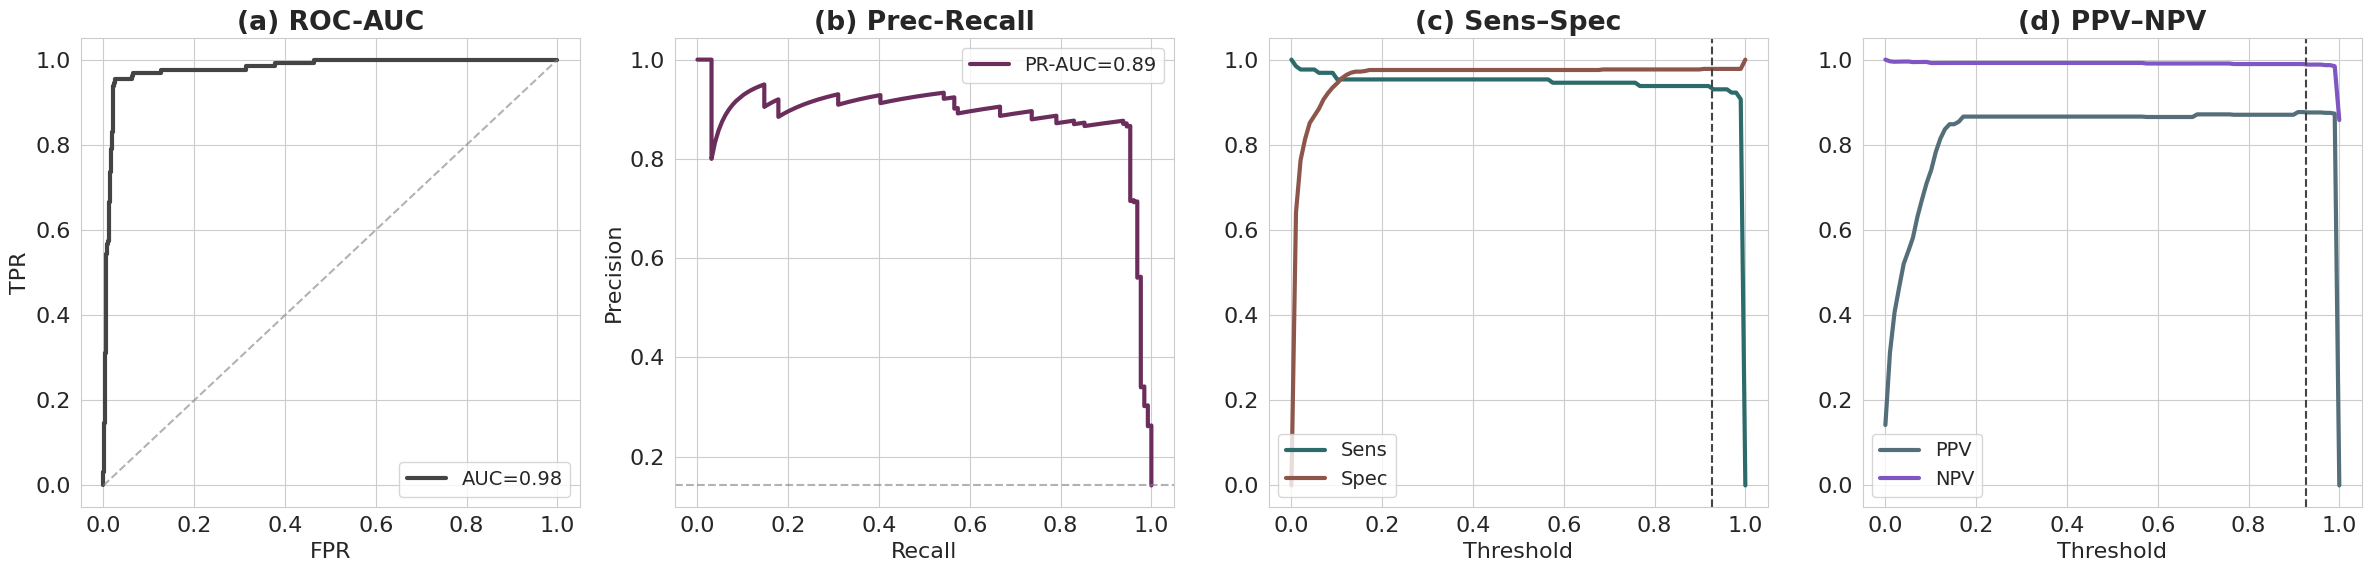

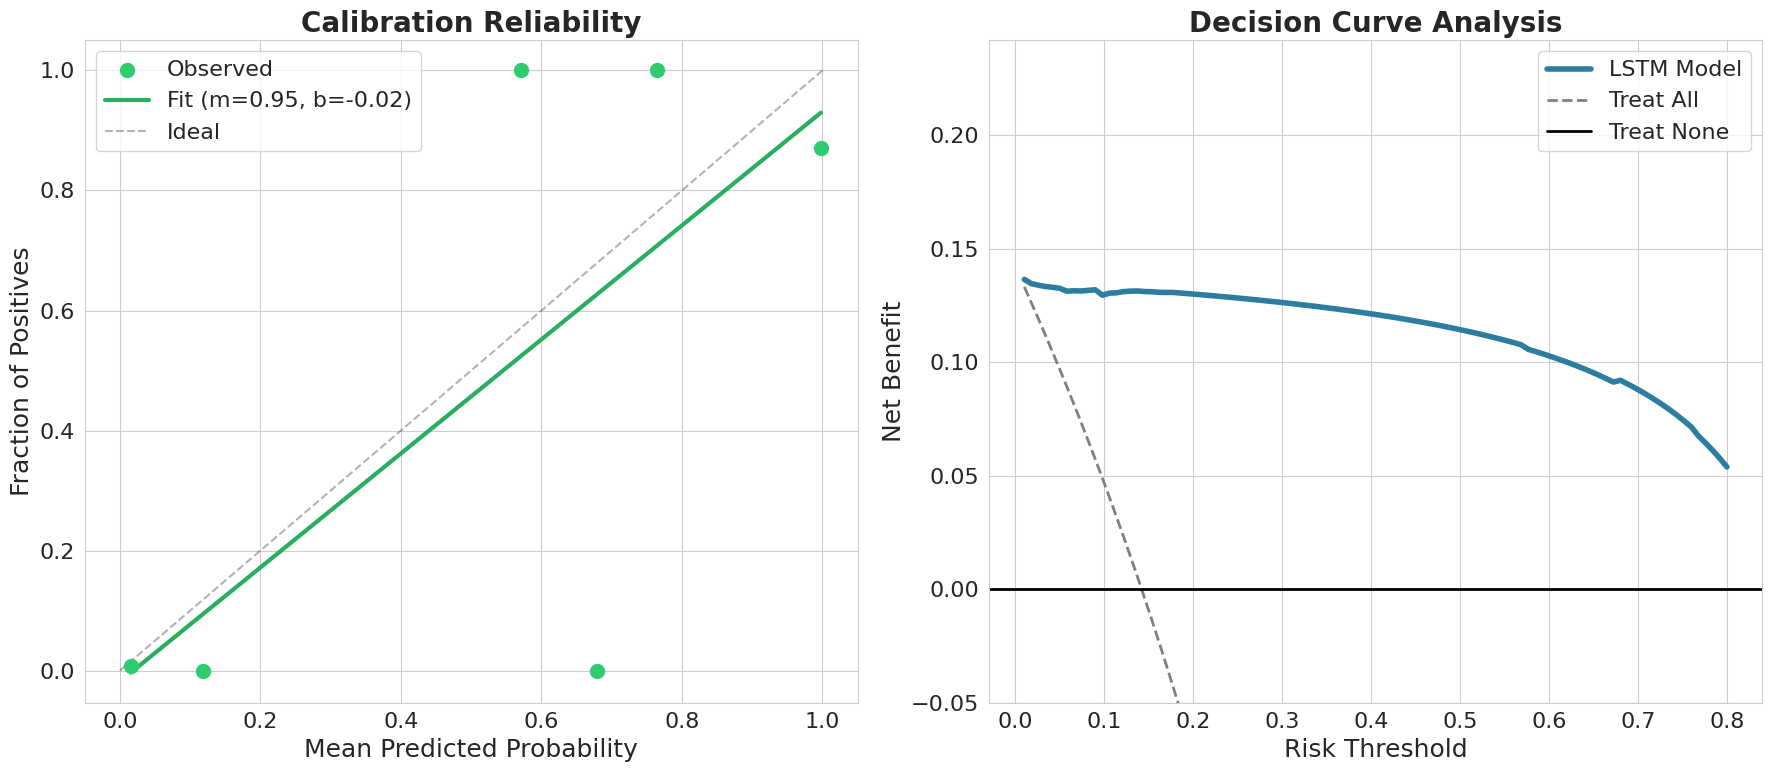

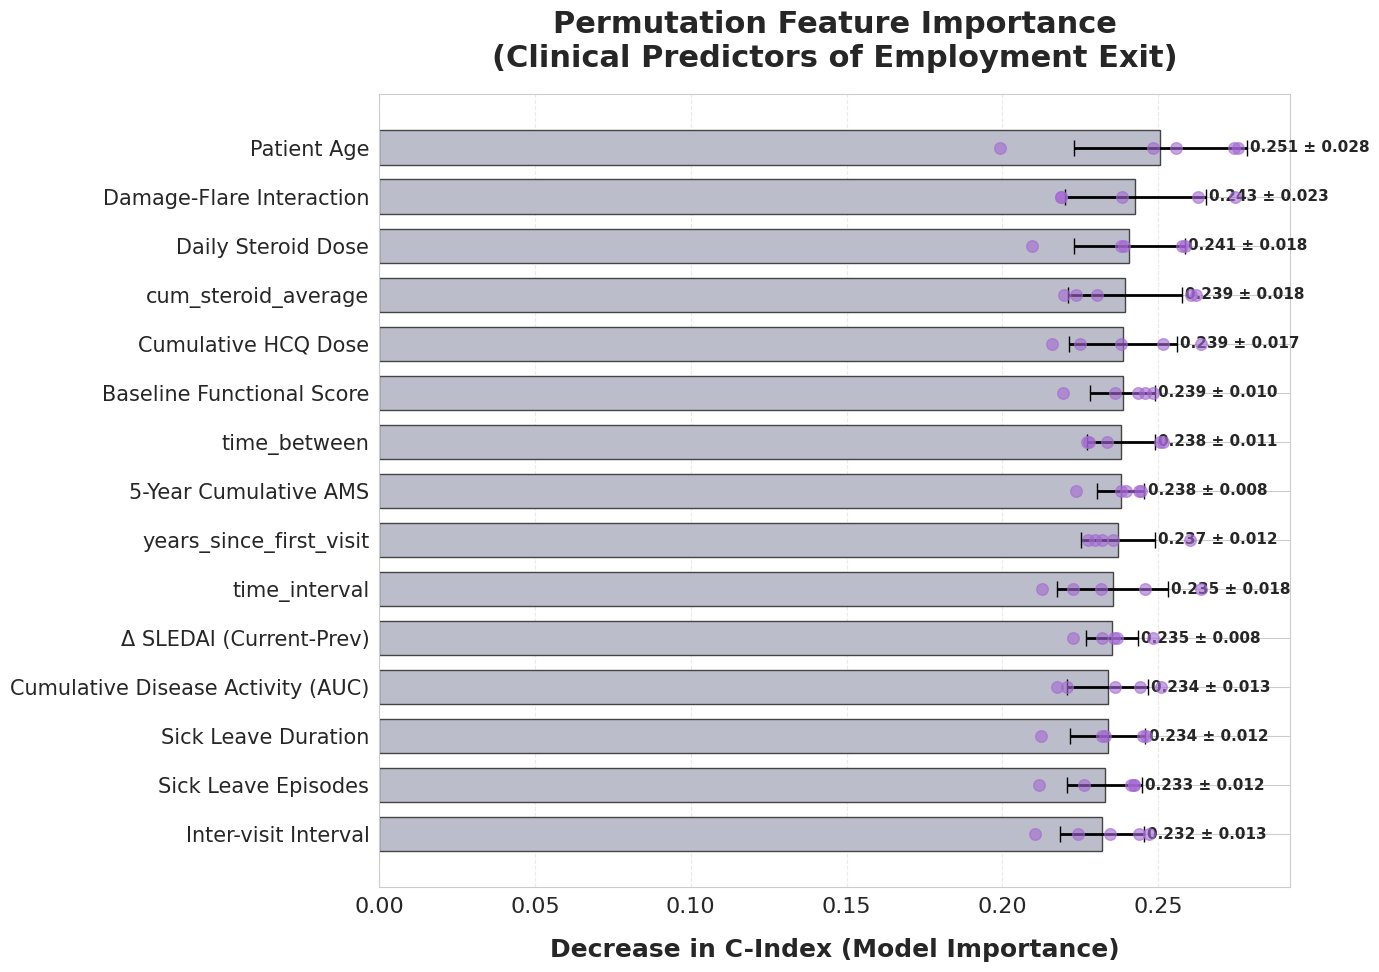

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from lifelines.utils import concordance_index

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({'font.size': 16})
sns.set_style("whitegrid")

class DisabilityModelEvaluator:
    def __init__(self, model, feature_cols, final_scaler=None):
        """
        Args:
            model: Trained Keras/TF model.
            feature_cols: List of feature names in the order they appear in X.
            final_scaler: Optional scaler used on model output risk scores.
        """
        self.model = model
        self.feature_cols = feature_cols
        self.final_scaler = final_scaler

    def plot_performance_grid(self, y_true, y_prob, best_t):
        fig, axes = plt.subplots(1, 4, figsize=(24, 6))

        # (a) ROC-AUC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, color='#444444', lw=3, label=f'AUC={roc_auc:.2f}')
        axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.6)
        axes[0].set_title('(a) ROC-AUC', fontweight='bold')
        axes[0].set_xlabel('FPR')
        axes[0].set_ylabel('TPR')
        axes[0].legend(loc='lower right', fontsize=14)

        # (b) Precision-Recall
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)
        axes[1].plot(recall, precision, color='#6b2d5c', lw=3, label=f'PR-AUC={pr_auc:.2f}')
        axes[1].axhline(y=np.mean(y_true), color='gray', linestyle='--', alpha=0.6)
        axes[1].set_title('(b) Prec-Recall', fontweight='bold')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].legend(loc='upper right', fontsize=14)

        # (c) Sensitivity-Specificity
        th_range = np.linspace(0, 1, 100)
        sens, spec = [], []
        for t in th_range:
            preds = (y_prob >= t).astype(int)
            # Use flatten to ensure we handle confusion matrix safely
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
            spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

        axes[2].plot(th_range, sens, color='#2d6b6b', lw=3, label='Sens')
        axes[2].plot(th_range, spec, color='#8c564b', lw=3, label='Spec')
        axes[2].axvline(best_t, color='#444444', linestyle='--')
        axes[2].set_title('(c) Sens–Spec', fontweight='bold')
        axes[2].set_xlabel('Threshold')
        axes[2].legend(loc='lower left', fontsize=14)

        # (d) PPV-NPV
        ppv, npv = [], []
        for t in th_range:
            preds = (y_prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            ppv.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
            npv.append(tn / (tn + fn) if (tn + fn) > 0 else 1)

        axes[3].plot(th_range, ppv, color='#546e7a', lw=3, label='PPV')
        axes[3].plot(th_range, npv, color='#7e57c2', lw=3, label='NPV')
        axes[3].axvline(best_t, color='#444444', linestyle='--')
        axes[3].set_title('(d) PPV–NPV', fontweight='bold')
        axes[3].set_xlabel('Threshold')
        axes[3].legend(loc='lower left', fontsize=14)

        plt.tight_layout()
        plt.show()

    def plot_calibration_dca(self, y_true, y_prob):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

        # 1. Calibration
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
        slope, intercept, r_val, _, _ = stats.linregress(prob_pred, prob_true)
        line = slope * prob_pred + intercept

        ax1.scatter(prob_pred, prob_true, color='#2ecc71', s=100, label='Observed', zorder=5)
        ax1.plot(prob_pred, line, color='#27ae60', lw=3, label=f'Fit (m={slope:.2f}, b={intercept:.2f})')
        ax1.plot([0, 1], [0, 1], "k--", alpha=0.3, label='Ideal')
        ax1.set_title('Calibration Reliability', fontweight='bold', size=20)
        ax1.set_xlabel('Mean Predicted Probability', size=18)
        ax1.set_ylabel('Fraction of Positives', size=18)
        ax1.legend(fontsize=16)

        # 2. DCA
        thresholds = np.linspace(0.01, 0.8, 100)
        n, prev = len(y_true), np.mean(y_true)
        nb_model = [((np.sum((y_prob >= t) & (y_true == 1)) / n) -
                     (np.sum((y_prob >= t) & (y_true == 0)) / n) * (t / (1 - t))) for t in thresholds]
        nb_all = [prev - (1 - prev) * (t / (1 - t)) for t in thresholds]

        ax2.plot(thresholds, nb_model, color='#2c7da0', lw=4, label='LSTM Model')
        ax2.plot(thresholds, nb_all, color='gray', linestyle='--', lw=2, label='Treat All')
        ax2.axhline(0, color='black', lw=2, label='Treat None')
        ax2.set_title('Decision Curve Analysis', fontweight='bold', size=20)
        ax2.set_xlabel('Risk Threshold', size=18)
        ax2.set_ylabel('Net Benefit', size=18)
        ax2.set_ylim([-0.05, prev + 0.1])
        ax2.legend(fontsize=16)

        plt.tight_layout()
        plt.show()

    def plot_permutation_importance(self, X, tte, events, baseline_cindex):
        """Updated with name mapping and fixed index handling for 2D outputs."""
        name_map = {
            'score_n': 'Baseline Functional Score',
            'sledai_change': 'Δ SLEDAI (Current-Prev)',
            'cumulative_AMS_5yrs': '5-Year Cumulative AMS',
            'previous_sledai': 'Previous Visit SLEDAI',
            'visit_num': 'Total Visit Count',
            'days_since_last_visit': 'Days Since Last Visit',
            'sick_leave_duration': 'Sick Leave Duration',
            'STERDOSE': 'Daily Steroid Dose',
            'AMS': 'Adjusted Mean SLEDAI',
            'cum_area': 'Cumulative Disease Activity (AUC)',
            'time_since_dx': 'Years Since Diagnosis',
            'sick_leave_spell': 'Sick Leave Episodes',
            'cum_am_hydroxychloroquine': 'Cumulative HCQ Dose',
            'visits_last_year': 'Annual Visit Frequency',
            'time_between_visits': 'Inter-visit Interval',
            'age_at_record': 'Patient Age',
            'sdi_flare_interaction': 'Damage-Flare Interaction',
            'STERAVER': 'Average Steroid Dose Since Last Visit',
            'SLEDAI2_I': 'SLEDAI-2K Score',
            'cum_ster_dose': 'Cumulative Steroid Dose'
        }

        results = []
        n_repeats = 5

        for i, internal_name in enumerate(self.feature_cols):
            display_name = name_map.get(internal_name, internal_name)
            diffs = []

            for _ in range(n_repeats):
                X_permuted = X.copy()
                shuffled_indices = np.random.permutation(len(X))
                X_permuted[:, :, i] = X_permuted[shuffled_indices, :, i]

                raw_preds = self.model.predict(X_permuted, verbose=0)

                # --- FIX: ROBUST DIMENSION HANDLING ---
                if raw_preds.ndim == 3:
                    perm_risks_raw = raw_preds[:, -1, 0] # [samples, time, output]
                elif raw_preds.ndim == 2:
                    perm_risks_raw = raw_preds[:, 0]     # [samples, output]
                else:
                    perm_risks_raw = raw_preds           # [samples]

                if self.final_scaler:
                    perm_risks = self.final_scaler.transform(perm_risks_raw.reshape(-1, 1)).flatten()
                else:
                    perm_risks = perm_risks_raw

                # C-index calculation (1 - risk used for discrimination)
                new_cindex = concordance_index(tte, 1 - perm_risks, events)
                diffs.append(baseline_cindex - new_cindex)

            results.append({
                'Feature': display_name,
                'Mean': np.mean(diffs),
                'SD': np.std(diffs),
                'Values': diffs
            })

        importance_df = pd.DataFrame(results).sort_values(by='Mean', ascending=False)[:15]

        plt.figure(figsize=(14, 10))
        y_pos = np.arange(len(importance_df))

        # Plotting
        plt.barh(y_pos, importance_df['Mean'], color='#bcbdca', edgecolor='#444444', height=0.7)

        for idx, row in enumerate(importance_df.itertuples()):
            plt.errorbar(row.Mean, idx, xerr=row.SD, fmt='none', ecolor='black', capsize=6, elinewidth=2, zorder=3)
            plt.scatter(row.Values, [idx]*len(row.Values), color='#a368d1', s=70, alpha=0.6, zorder=4)
            plt.text(row.Mean + row.SD + 0.001, idx, f"{row.Mean:.3f} ± {row.SD:.3f}",
                    va='center', fontweight='bold', fontsize=11)

        plt.yticks(y_pos, importance_df['Feature'], fontsize=15)
        plt.gca().invert_yaxis()
        plt.xlabel("Decrease in C-Index (Model Importance)", fontweight='bold', fontsize=18, labelpad=15)
        plt.title("Permutation Feature Importance\n(Clinical Predictors of Employment Exit)", fontweight='bold', fontsize=22, pad=20)
        plt.grid(axis='x', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

# --- EXECUTION ---
# 1. Initialize with your specific model and features
evaluator = DisabilityModelEvaluator(final_model, selected_features)

# 2. Run the performance metrics
evaluator.plot_performance_grid(y_true_dis, y_prob_dis, opt_thresh_dis)
evaluator.plot_calibration_dca(y_true_dis, y_prob_dis)

# 3. Calculate baseline C-Index and run the importance plot
base_c = concordance_index(time_to_event_array, 1 - y_prob_dis, event_observed_array)
evaluator.plot_permutation_importance(X_seq, time_to_event_array, event_observed_array, base_c)

In [6]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=a53bdc4691779bcd03031200671a49d23f2c58345cf37c68f6f7916cca9692b2
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


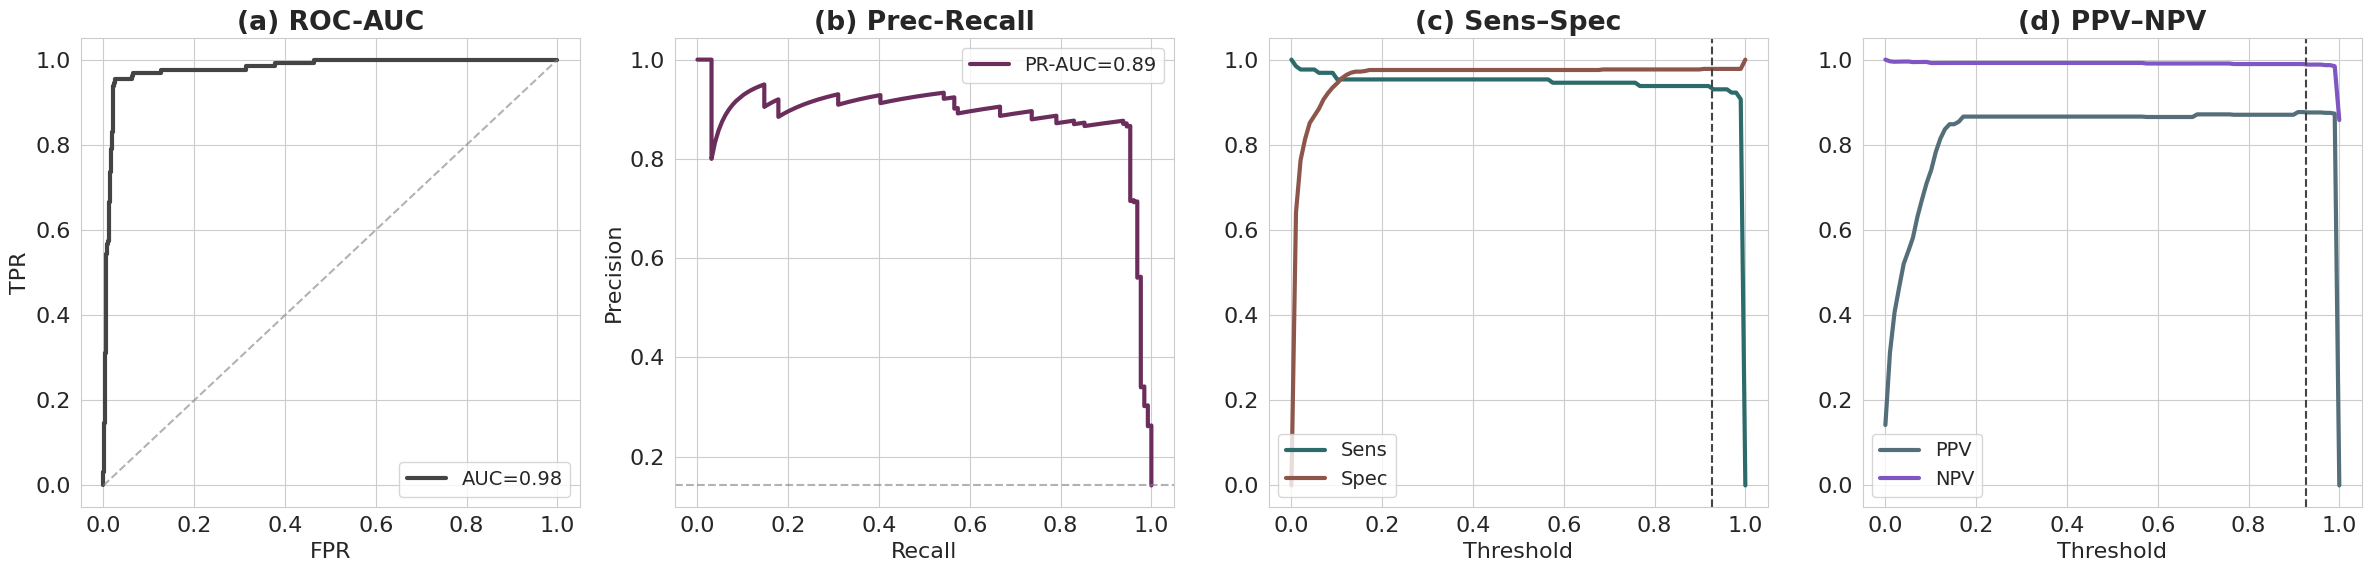

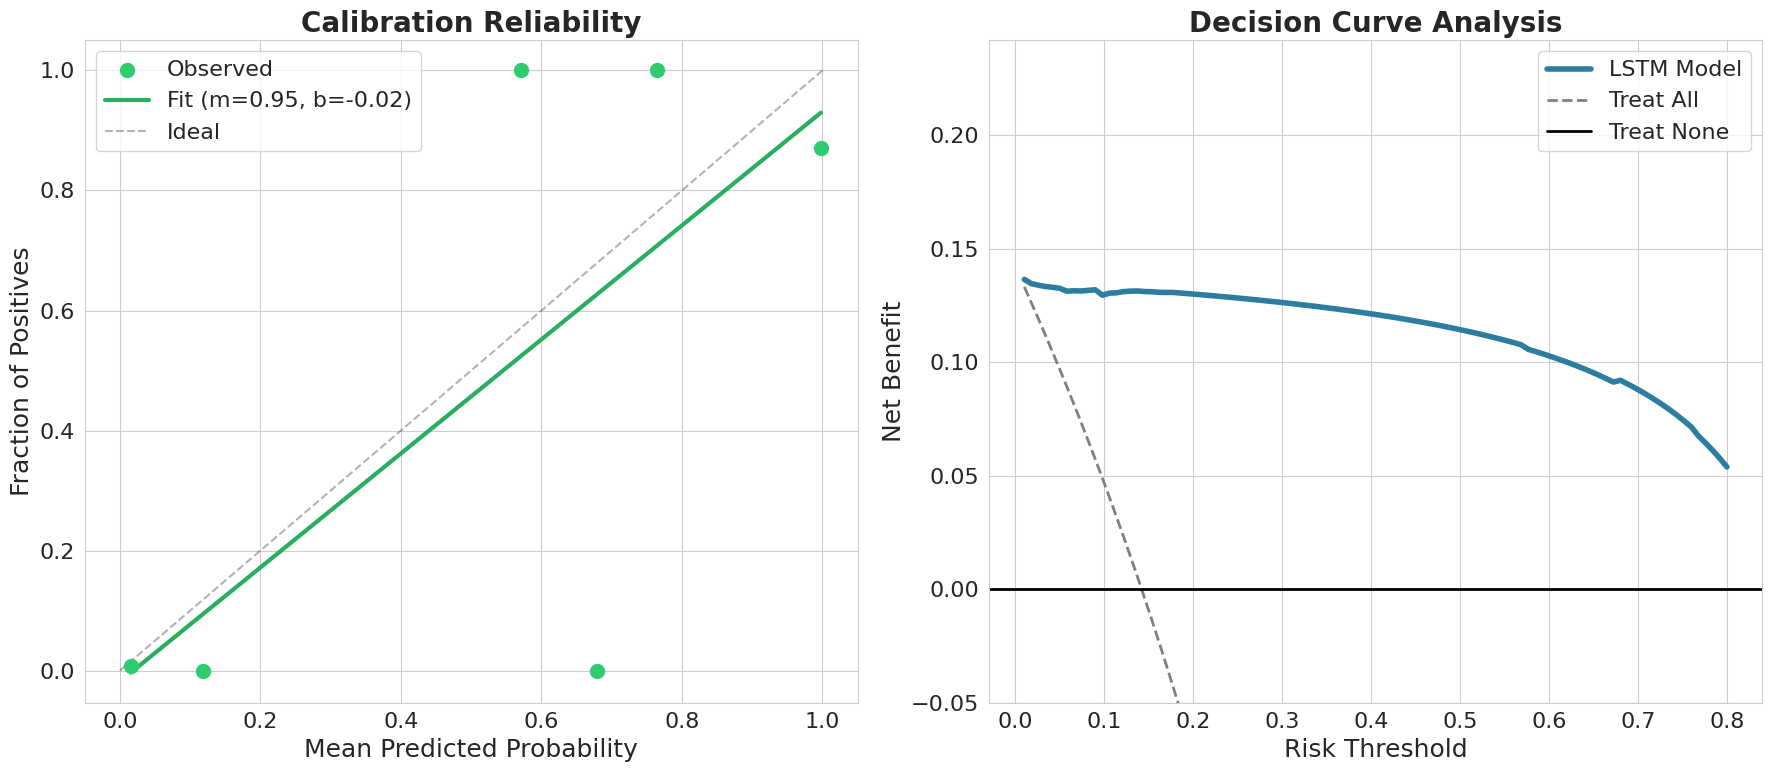

/tmp/ipython-input-3018930453.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Drop', y='Feature', data=imp_df, palette='viridis')


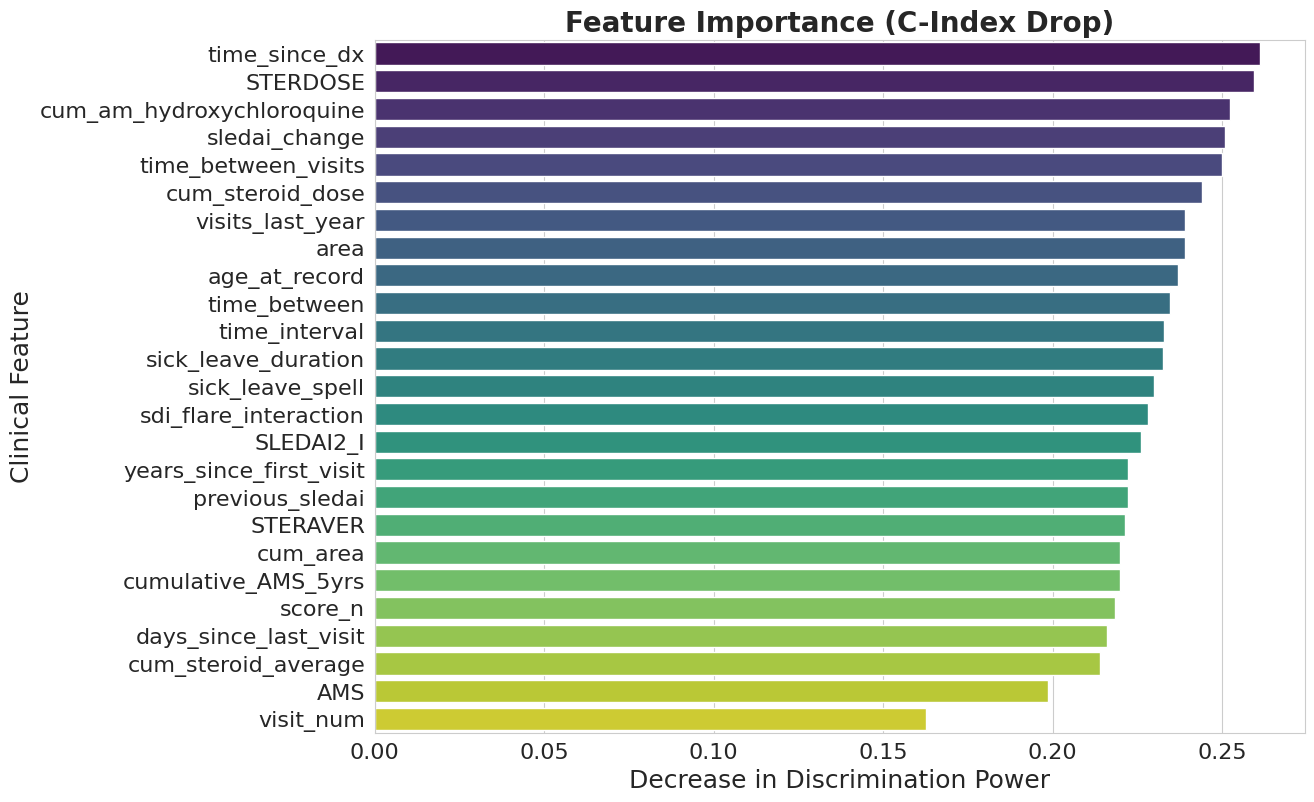

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import (confusion_matrix, balanced_accuracy_score,
                             roc_auc_score, average_precision_score,
                             roc_curve, auc, precision_recall_curve)
from sklearn.calibration import calibration_curve
from lifelines.utils import concordance_index

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({'font.size': 16})
sns.set_style("whitegrid")

# --- 1. PREPARE SURVIVAL ARRAYS FOR DISABILITY ---
survival_records = []
for ptno, patient_data in data.groupby('PTNO'):
    patient_data = patient_data.sort_values('ASSDT')
    duration = (patient_data['ASSDT'].iloc[-1] - patient_data['ASSDT'].iloc[0]).days / 30.44
    event = 1 if patient_data['end_state_encoded'].iloc[-1] == 0 else 0
    survival_records.append({'PTNO': ptno, 'duration': duration, 'event': event})

surv_df = pd.merge(results_df[['PTNO']], pd.DataFrame(survival_records), on='PTNO', how='left')
time_to_event_array = surv_df['duration'].values
event_observed_array = surv_df['event'].values

y_true_dis = (results_df['final_outcome'] == 0).astype(int)
y_prob_dis = results_df['max_disability_risk'].values
opt_thresh_dis = thresholds['disability']

# --- 2. THE COMPREHENSIVE EVALUATOR CLASS ---
class DisabilityModelEvaluator:
    def __init__(self, model, feature_cols):
        self.model = model
        self.feature_cols = feature_cols

    def plot_performance_grid(self, y_true, y_prob, best_t):
        fig, axes = plt.subplots(1, 4, figsize=(24, 6))

        # (a) ROC-AUC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, color='#444444', lw=3, label=f'AUC={roc_auc:.2f}')
        axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.6)
        axes[0].set_title('(a) ROC-AUC', fontweight='bold')
        axes[0].set_xlabel('FPR')
        axes[0].set_ylabel('TPR')
        axes[0].legend(loc='lower right', fontsize=14)

        # (b) Precision-Recall
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)
        axes[1].plot(recall, precision, color='#6b2d5c', lw=3, label=f'PR-AUC={pr_auc:.2f}')
        axes[1].axhline(y=np.mean(y_true), color='gray', linestyle='--', alpha=0.6)
        axes[1].set_title('(b) Prec-Recall', fontweight='bold')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].legend(loc='upper right', fontsize=14)

        # (c) Sensitivity-Specificity
        th_range = np.linspace(0, 1, 100)
        sens, spec = [], []
        for t in th_range:
            preds = (y_prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
            spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

        axes[2].plot(th_range, sens, color='#2d6b6b', lw=3, label='Sens')
        axes[2].plot(th_range, spec, color='#8c564b', lw=3, label='Spec')
        axes[2].axvline(best_t, color='#444444', linestyle='--')
        axes[2].set_title('(c) Sens–Spec', fontweight='bold')
        axes[2].set_xlabel('Threshold')
        axes[2].legend(loc='lower left', fontsize=14)

        # (d) PPV-NPV
        ppv, npv = [], []
        for t in th_range:
            preds = (y_prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            ppv.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
            npv.append(tn / (tn + fn) if (tn + fn) > 0 else 1)

        axes[3].plot(th_range, ppv, color='#546e7a', lw=3, label='PPV')
        axes[3].plot(th_range, npv, color='#7e57c2', lw=3, label='NPV')
        axes[3].axvline(best_t, color='#444444', linestyle='--')
        axes[3].set_title('(d) PPV–NPV', fontweight='bold')
        axes[3].set_xlabel('Threshold')
        axes[3].legend(loc='lower left', fontsize=14)

        for ax in axes:
            ax.tick_params(axis='both', which='major', labelsize=16)

        plt.tight_layout()
        plt.show()

    def plot_calibration_dca(self, y_true, y_prob):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

        # 1. Calibration Best Fit
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
        slope, intercept, r_val, _, _ = stats.linregress(prob_pred, prob_true)
        line = slope * prob_pred + intercept

        ax1.scatter(prob_pred, prob_true, color='#2ecc71', s=100, label='Observed', zorder=5)
        ax1.plot(prob_pred, line, color='#27ae60', lw=3, label=f'Fit (m={slope:.2f}, b={intercept:.2f})')
        ax1.plot([0, 1], [0, 1], "k--", alpha=0.3, label='Ideal')
        ax1.set_title('Calibration Reliability', fontweight='bold', size=20)
        ax1.set_xlabel('Mean Predicted Probability', size=18)
        ax1.set_ylabel('Fraction of Positives', size=18)
        ax1.tick_params(labelsize=16)
        ax1.legend(fontsize=16)

        # 2. DCA
        thresholds = np.linspace(0.01, 0.8, 100)
        n, prev = len(y_true), np.mean(y_true)
        nb_model = [((np.sum((y_prob >= t) & (y_true == 1)) / n) -
                     (np.sum((y_prob >= t) & (y_true == 0)) / n) * (t / (1 - t))) for t in thresholds]
        nb_all = [prev - (1 - prev) * (t / (1 - t)) for t in thresholds]

        ax2.plot(thresholds, nb_model, color='#2c7da0', lw=4, label='LSTM Model')
        ax2.plot(thresholds, nb_all, color='gray', linestyle='--', lw=2, label='Treat All')
        ax2.axhline(0, color='black', lw=2, label='Treat None')
        ax2.set_title('Decision Curve Analysis', fontweight='bold', size=20)
        ax2.set_xlabel('Risk Threshold', size=18)
        ax2.set_ylabel('Net Benefit', size=18)
        ax2.set_ylim([-0.05, prev + 0.1])
        ax2.tick_params(labelsize=16)
        ax2.legend(fontsize=16)

        plt.tight_layout()
        plt.show()

    def plot_permutation_importance(self, X, tte, events, base_cindex):
        importances = []
        for i, col in enumerate(self.feature_cols):
            X_permuted = X.copy()
            X_permuted[:, :, i] = X_permuted[np.random.permutation(len(X)), :, i]
            raw_preds = self.model.predict(X_permuted, verbose=0)
            new_c = concordance_index(tte, 1 - raw_preds[:, 0], events)
            importances.append(base_cindex - new_c)

        imp_df = pd.DataFrame({'Feature': self.feature_cols, 'Drop': importances}).sort_values('Drop', ascending=False)
        plt.figure(figsize=(12, 9))
        sns.barplot(x='Drop', y='Feature', data=imp_df, palette='viridis')
        plt.title('Feature Importance (C-Index Drop)', fontweight='bold', size=20)
        plt.xlabel('Decrease in Discrimination Power', size=18)
        plt.ylabel('Clinical Feature', size=18)
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.show()

# --- 3. EXECUTION ---
evaluator = DisabilityModelEvaluator(final_model, selected_features)
evaluator.plot_performance_grid(y_true_dis, y_prob_dis, opt_thresh_dis)
evaluator.plot_calibration_dca(y_true_dis, y_prob_dis)

base_c = concordance_index(time_to_event_array, 1 - y_prob_dis, event_observed_array)
evaluator.plot_permutation_importance(X_seq, time_to_event_array, event_observed_array, base_c)

In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, classification_report,
                           roc_auc_score, precision_recall_curve,
                           average_precision_score, roc_curve,
                           precision_score, recall_score)  # Added imports here
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal loss for handling class imbalance
    """
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        pt = tf.where(K.equal(y_true, 1), y_pred, 1 - y_pred)
        return -K.mean(alpha * K.pow(1. - pt, gamma) * K.log(pt))
    return focal_loss_fixed

def find_balanced_threshold(y_true, y_scores, min_recall=0.8):
    """
    Find threshold that maintains minimum recall while maximizing precision
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)

    # Find threshold that maintains min recall while maximizing precision
    valid_idx = np.where(recalls >= min_recall)[0]
    if len(valid_idx) > 0:
        best_idx = np.argmax(precisions[valid_idx])
        return thresholds[best_idx]
    return 0.5

def find_early_detection_threshold(y_true, y_scores, timing_data=None, min_sensitivity=0.9):
    """
    Find threshold that optimizes for early detection while maintaining sensitivity
    """
    # Calculate ROC curve metrics
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    # Filter thresholds that meet minimum sensitivity
    valid_idx = np.where(tpr >= min_sensitivity)[0]
    if len(valid_idx) == 0:
        return 0.5, {}  # Fallback if no threshold meets sensitivity

    # Get subset of thresholds that meet sensitivity
    valid_thresholds = thresholds[valid_idx]
    valid_tpr = tpr[valid_idx]

    # If no timing data, just return the threshold with highest sensitivity
    if timing_data is None:
        best_idx = np.argmax(valid_tpr)
        optimal_threshold = valid_thresholds[best_idx]
        return optimal_threshold, {}

    # For each candidate threshold, calculate detection timing
    detection_stats = []
    for thresh in valid_thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        detected_times = [t for t in timing_data if t > 0]
        avg_detection_time = np.mean(detected_times) if detected_times else 0
        detection_rate = len(detected_times) / sum(y_true)

        detection_stats.append({
            'threshold': thresh,
            'sensitivity': valid_tpr[np.where(valid_thresholds == thresh)[0][0]],
            'avg_detection_time': avg_detection_time,
            'detection_rate': detection_rate
        })

    # Select threshold with best (earliest) average detection time
    detection_stats = pd.DataFrame(detection_stats)
    best_idx = detection_stats['avg_detection_time'].idxmax()
    optimal_threshold = detection_stats.loc[best_idx, 'threshold']

    return optimal_threshold, detection_stats

def assess_patient_risk_with_early_warning(patient_data, model, temporal_features,
                                         max_seq_length, disability_threshold=0.15,
                                         death_threshold=0.15, early_warning_factor=0.7):
    """
    Enhanced risk assessment with separate early warning signals
    """
    risks = []
    patient_data = patient_data.sort_values('ASSDT')
    disability_warning_threshold = disability_threshold * early_warning_factor
    death_warning_threshold = death_threshold * early_warning_factor

    for i in range(1, len(patient_data)+1):
        current_visit = patient_data.iloc[:i]
        current_row = current_visit.iloc[-1]

        # Prepare sequence data
        seq_len = len(current_visit)
        seq_data = np.zeros((1, max_seq_length, len(temporal_features)))
        seq_data[0, :seq_len, :] = current_visit[temporal_features].values

        # Get prediction probabilities for all classes
        pred_probas = model.predict(seq_data, verbose=0)[0]

        # Class 0 is disability, class 2 is death
        disability_prob = pred_probas[0]
        death_prob = pred_probas[2]

        risks.append({
            'visit_date': current_row['ASSDT'],
            'visit_number': i,
            'disability_risk': disability_prob,
            'death_risk': death_prob,
            'disability_flagged': disability_prob >= disability_threshold,
            'death_flagged': death_prob >= death_threshold,
            'disability_warning': disability_prob >= disability_warning_threshold,
            'death_warning': death_prob >= death_warning_threshold
        })

    return pd.DataFrame(risks)

def evaluate_patients_with_early_detection(data, model, temporal_features,
                                         max_seq_length, timing_data=None):
    """
    Enhanced evaluation with improved death modeling
    """
    results = []
    timing_analysis = {
        'disability': [],
        'death': []
    }
    all_scores = {
        'disability': [],
        'death': []
    }
    all_outcomes = {
        'disability': [],
        'death': []
    }

    # First pass to collect all scores and outcomes
    for ptno, patient_data in data.groupby('PTNO'):
        patient_data = patient_data.sort_values('ASSDT')
        final_outcome = patient_data['end_state_encoded'].iloc[-1]

        risk_df = assess_patient_risk_with_early_warning(
            patient_data,
            model,
            temporal_features,
            max_seq_length,
            disability_threshold=0.5,
            death_threshold=0.5
        )

        all_scores['disability'].append(risk_df['disability_risk'].max())
        all_scores['death'].append(risk_df['death_risk'].max())
        all_outcomes['disability'].append(final_outcome == 0)
        all_outcomes['death'].append(final_outcome == 2)

    # Find optimal thresholds
    thresholds = {}
    detection_stats = {}

    # For disability (original approach works well)
    y_true_disability = np.array(all_outcomes['disability']).astype(int)
    y_scores_disability = np.array(all_scores['disability'])

    if timing_data is None or 'disability' not in timing_data:
        disability_timing = []
        for ptno, patient_data in data.groupby('PTNO'):
            patient_data = patient_data.sort_values('ASSDT')
            final_outcome = patient_data['end_state_encoded'].iloc[-1]

            if final_outcome == 0:
                risk_df = assess_patient_risk_with_early_warning(
                    patient_data,
                    model,
                    temporal_features,
                    max_seq_length
                )

                first_flag = risk_df[risk_df['disability_flagged']]['visit_date'].min()
                if pd.notna(first_flag):
                    months_before = (patient_data['ASSDT'].iloc[-1] - first_flag).days / 30
                    disability_timing.append(months_before)
                else:
                    disability_date = patient_data['ASSDT'].iloc[-1]
                    last_visit_date = patient_data['ASSDT'].iloc[-2] if len(patient_data) > 1 else disability_date
                    months_after = (disability_date - last_visit_date).days / 30
                    disability_timing.append(-months_after)
        timing_analysis['disability'] = disability_timing
    else:
        timing_analysis['disability'] = timing_data['disability']

    thresholds['disability'], detection_stats['disability'] = find_early_detection_threshold(
        y_true_disability, y_scores_disability, timing_analysis['disability']
    )

    # For death - use balanced approach
    y_true_death = np.array(all_outcomes['death']).astype(int)
    y_scores_death = np.array(all_scores['death'])

    thresholds['death'] = find_balanced_threshold(y_true_death, y_scores_death, min_recall=0.8)
    detection_stats['death'] = {
        'threshold': thresholds['death'],
        'precision': precision_score(y_true_death, y_scores_death >= thresholds['death']),
        'recall': recall_score(y_true_death, y_scores_death >= thresholds['death'])
    }

    # Second pass with optimal thresholds
    for ptno, patient_data in data.groupby('PTNO'):
        patient_data = patient_data.sort_values('ASSDT')
        final_outcome = patient_data['end_state_encoded'].iloc[-1]

        risk_df = assess_patient_risk_with_early_warning(
            patient_data,
            model,
            temporal_features,
            max_seq_length,
            disability_threshold=thresholds['disability'],
            death_threshold=thresholds['death']
        )

        first_disability_flag = risk_df[risk_df['disability_flagged']]['visit_date'].min()
        first_death_flag = risk_df[risk_df['death_flagged']]['visit_date'].min()
        first_disability_warning = risk_df[risk_df['disability_warning']]['visit_date'].min()
        first_death_warning = risk_df[risk_df['death_warning']]['visit_date'].min()

        results.append({
            'PTNO': ptno,
            'final_outcome': final_outcome,
            'ever_disability_flagged': any(risk_df['disability_flagged']),
            'ever_death_flagged': any(risk_df['death_flagged']),
            'ever_disability_warned': any(risk_df['disability_warning']),
            'ever_death_warned': any(risk_df['death_warning']),
            'first_disability_flag_date': first_disability_flag,
            'first_death_flag_date': first_death_flag,
            'first_disability_warning_date': first_disability_warning,
            'first_death_warning_date': first_death_warning,
            'max_disability_risk': risk_df['disability_risk'].max(),
            'max_death_risk': risk_df['death_risk'].max(),
            'final_disability_risk': risk_df['disability_risk'].iloc[-1],
            'final_death_risk': risk_df['death_risk'].iloc[-1],
            'num_visits': len(patient_data)
        })

    return pd.DataFrame(results), timing_analysis, thresholds, detection_stats

def analyze_results_with_improved_death_model(results_df, timing_data, thresholds, detection_stats):
    """
    Enhanced analysis with better death modeling metrics
    """
    # Disability analysis (unchanged)
    disability_true = (results_df['final_outcome'] == 0).astype(int)
    disability_pred_alert = results_df['ever_disability_flagged'].astype(int)
    disability_scores = results_df['max_disability_risk']

    # Death analysis with improved metrics
    death_true = (results_df['final_outcome'] == 2).astype(int)
    death_pred_alert = results_df['ever_death_flagged'].astype(int)
    death_scores = results_df['max_death_risk']

    print("\n=== Disability Early Detection Performance ===")
    print(f"Using threshold: {thresholds['disability']:.4f}")
    print(f"Early warning threshold: {thresholds['disability']*0.7:.4f}")

    disability_timing = np.array(timing_data['disability'])
    disability_detections = disability_timing[disability_timing > 0]

    if len(disability_detections) > 0:
        print(f"\nAverage detection time (months): {np.mean(disability_detections):.1f}")
        print(f"Median detection time: {np.median(disability_detections):.1f}")
        print(f"Detection rate: {len(disability_detections)}/{sum(disability_true)} ({len(disability_detections)/sum(disability_true):.1%})")

    print("\nConfusion Matrix (Disability):")
    print(confusion_matrix(disability_true, disability_pred_alert))
    print("\nClassification Report (Disability):")
    print(classification_report(disability_true, disability_pred_alert))
    print(f"\nROC AUC: {roc_auc_score(disability_true, disability_scores):.4f}")
    print(f"Average Precision: {average_precision_score(disability_true, disability_scores):.4f}")

    print("\n=== Improved Death Detection Performance ===")
    print(f"Using balanced threshold: {thresholds['death']:.4f}")
    print(f"Early warning threshold: {thresholds['death']*0.7:.4f}")

    print("\nConfusion Matrix (Death):")
    print(confusion_matrix(death_true, death_pred_alert))
    print("\nClassification Report (Death):")
    print(classification_report(death_true, death_pred_alert))
    print(f"\nROC AUC: {roc_auc_score(death_true, death_scores):.4f}")
    print(f"Average Precision: {average_precision_score(death_true, death_scores):.4f}")

    # Plot precision-recall curve for death
    precision, recall, _ = precision_recall_curve(death_true, death_scores)
    plt.figure(figsize=(10, 5))
    plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Death Risk Precision-Recall Curve')
    plt.axvline(x=0.8, color='r', linestyle='--', label='Target Recall')
    plt.legend()
    plt.show()

# Example Usage
if __name__ == "__main__":
    # Assuming you have these defined:
    # data = your patient data
    # final_model = your trained LSTM model
    # selected_features = your temporal features
    # X_seq = your sequence data (for getting max_seq_length)

    max_seq_length = X_seq.shape[1]

    # Run evaluation with improved death modeling
    results_df, timing_data, thresholds, det_stats = evaluate_patients_with_early_detection(
        data,
        final_model,
        temporal_features=selected_features,
        max_seq_length=max_seq_length
    )

    # Analyze results
    analyze_results_with_improved_death_model(results_df, timing_data, thresholds, det_stats)

KeyboardInterrupt: 

In [ ]:
def plot_patient_trajectory(patient_data, risk_df, ptno):
    """
    Plot individual patient trajectory with risk scores (left axis) and
    clinical variables (right axis) on a single plot.
    """
    # Data preparation
    patient_data = patient_data.copy()
    risk_df = risk_df.copy()

    # Convert and merge data
    patient_data['ASSDT'] = pd.to_datetime(patient_data['ASSDT'])
    risk_df['visit_date'] = pd.to_datetime(risk_df['visit_date'])
    merged = pd.merge(patient_data, risk_df,
                    left_on='ASSDT',
                    right_on='visit_date',
                    how='left')

    # Calculate patient age
    birth_date = pd.to_datetime(merged['BIRTHDT'].iloc[0])
    merged['age'] = (merged['ASSDT'] - birth_date).dt.days / 365.25

    # Create figure with dual axes
    fig, ax = plt.subplots(figsize=(14, 8))
    ax_right = ax.twinx()

    # Plot risk scores on left axis
    ax.plot(merged['age'], merged['disability_risk'],
           label='Disability Risk', color='blue', linewidth=2)

    # Plot clinical variables on right axis
    if 'SLEDAI2_I' in merged.columns:
        ax_right.plot(merged['age'], merged['SLEDAI2_I'],
                     label='SLEDAI', color='green', linestyle='--')
    if 'STERDOSE' in merged.columns:
        ax_right.plot(merged['age'], merged['STERDOSE'],
                     label='Steroid Dose', color='purple', linestyle=':')
    if 'AMS' in merged.columns:
        ax_right.plot(merged['age'], merged['AMS'],
                     label='AMS', color='orange', linestyle='-.')

    # Mark key events
    if 'disability_flagged' in merged.columns:
        flags = merged[merged['disability_flagged']]
        if not flags.empty:
            ax.scatter(flags['age'], flags['disability_risk'],
                      color='blue', marker='x', s=100, label='Disability Flag')

    if 'EMP' in merged.columns:
        exit_idx = merged[merged['EMP'] == 0].index.min()
        if not pd.isna(exit_idx):
            exit_age = merged.loc[exit_idx, 'age']
            ax.axvline(x=exit_age, color='black', linewidth=2, label='Work Exit')

    # Formatting
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Risk Score (0-1)', color='black')
    ax_right.set_ylabel('Clinical Variables', color='black')

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    ax.legend(lines + lines_right, labels + labels_right, loc='upper left')

    # Set colors for axes
    ax.tick_params(axis='y', colors='black')
    ax_right.tick_params(axis='y', colors='black')

    # Set limits
    ax.set_ylim(0, 1)
    if 'SLEDAI2_I' in merged.columns:
        ax_right.set_ylim(0, merged['SLEDAI2_I'].max() * 1.2)

    plt.title(f'Patient {ptno} Trajectory\nFinal Outcome: {merged["end_state"].iloc[-1]}')
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    # Get example patient
    case_patient = results_df[results_df['final_outcome'].isin([0, 2])].iloc[2]
    ptno = case_patient['PTNO']

    patient_data = data[data['PTNO'] == ptno].sort_values('ASSDT')
    risk_df = assess_patient_risk_with_early_warning(
        patient_data,
        final_model,
        selected_features,
        max_seq_length,
        disability_threshold=thresholds['disability'],
        death_threshold=thresholds['death']
    )

    plot_patient_trajectory(patient_data, risk_df, ptno)

In [ ]:
data['severe_flare']

In [ ]:
def plot_patient_trajectory(patient_data, risk_df, ptno, data_orig):
    """
    Plot individual patient trajectory with:
    - Risk scores (left axis)
    - Clinical variables (right axes, properly unscaled)
    - Flare events from original data
    - Disability onset marker
    - Detailed employment transition markers
    """
    # Known variable ranges for reference
    VAR_RANGES = {
        'SLEDAI2_I': (0, 105),
        'STERDOSE': (0, 100),
        'AMS': (0, 4),
        'score_n': (0, 1)
    }

    # Employment status mapping
    EMP_STATUS = {
        0: 'Unemployed',
        1: 'Employed',
        2: 'Sick Leave',
        3: 'Retired',
        4: 'Disabled'
    }

    # Prepare data
    patient_data = patient_data.copy()
    risk_df = risk_df.copy()
    patient_data['ASSDT'] = pd.to_datetime(patient_data['ASSDT'])
    risk_df['visit_date'] = pd.to_datetime(risk_df['visit_date'])

    # Get original values including employment history
    orig_values = data_orig[data_orig['PTNO'] == ptno].sort_values('ASSDT')
    orig_values = orig_values[orig_values['ASSDT'].isin(patient_data['ASSDT'])]

    # Merge all data
    merged = pd.merge(patient_data, risk_df,
                     left_on='ASSDT',
                     right_on='visit_date',
                     how='left')

    # Add original values including flares and employment
    for col in ['SLEDAI2_I', 'STERDOSE', 'AMS', 'score_n', 'severe_flare', 'mild_flare', 'EMP']:
        if col in orig_values.columns:
            value_map = dict(zip(orig_values['ASSDT'], orig_values[col]))
            merged[col+'_orig'] = merged['ASSDT'].map(value_map)

    # Calculate patient age
    birth_date = pd.to_datetime(merged['BIRTHDT'].iloc[0])
    merged['age'] = (merged['ASSDT'] - birth_date).dt.days / 365.25

    # Create figure with multiple axes
    fig, ax = plt.subplots(figsize=(20, 8))

    # Create right axes for clinical variables
    ax_right_vars = {}
    colors = ['green', 'purple', 'orange', 'brown']
    for i, col in enumerate(['SLEDAI2_I_orig', 'STERDOSE_orig', 'AMS_orig', 'score_n_orig']):
        if col in merged.columns:
            ax_right = ax.twinx()
            ax_right.spines['right'].set_position(('outward', i*60))
            ax_right_vars[col] = ax_right

            # Set y-axis with 25% margin
            max_val = merged[col].max()
            upper_limit = max_val * 1.25 if max_val > 0 else 1.25
            ax_right.set_ylim(0, upper_limit)

            # Plot and label
            var_name = col.replace('_orig', '')
            label = 'Steroid Dose (mg)' if var_name == 'STERDOSE' else var_name
            ax_right.plot(merged['age'], merged[col],
                         label=label, color=colors[i],
                         linestyle=['-',':','-.','--'][i], alpha=0.8)
            ax_right.set_ylabel(label, color=colors[i])
            ax_right.tick_params(axis='y', labelcolor=colors[i])

    # Plot risk scores
    ax.plot(merged['age'], merged['disability_risk'],
           label='Disability Risk', color='blue', linewidth=2)

    # Mark flares
    for flare_type, color, y_pos in [('severe', 'darkred', 1.02), ('mild', 'gold', 1.0)]:
        col = f'{flare_type}_flare_orig'
        if col in merged.columns:
            flares = merged[merged[col] == 1]
            if not flares.empty:
                ax.scatter(flares['age'], [y_pos]*len(flares),
                          color=color, marker='v', s=100, label=f'{flare_type.title()} Flare')

    # Mark risk flags
    for risk_type, color in [('disability', 'blue')]:
        col = f'{risk_type}_flagged'
        if col in merged.columns:
            flags = merged[merged[col]]
            if not flags.empty:
                ax.scatter(flags['age'], flags[f'{risk_type}_risk'],
                          color=color, marker='x', s=100, label=f'{risk_type.title()} Flag')

    # Mark employment transitions
    if 'EMP_orig' in merged.columns:
        emp_changes = merged[merged['EMP_orig'].ne(merged['EMP_orig'].shift())]
        for _, row in emp_changes.iterrows():
            prev_emp = EMP_STATUS.get(merged.loc[row.name-1, 'EMP_orig'] if row.name > 0 else None, 'Unknown')
            new_emp = EMP_STATUS.get(row['EMP_orig'], 'Unknown')
            label = f"Emp: {prev_emp} → {new_emp}"

            ax.axvline(x=row['age'], color='gray', linestyle=':', alpha=0.7)
            ax.text(row['age'], 0.05, label, rotation=90, va='bottom', ha='right',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # Mark disability onset
    if 'end_state' in orig_values.columns:
        disability_dates = orig_values[orig_values['end_state'] == 'Disabled']['ASSDT']
        if not disability_dates.empty:
            disability_age = (disability_dates.iloc[0] - birth_date).days / 365.25
            ax.axvline(x=disability_age, color='blue', linestyle='--',
                      linewidth=2, label='Disability Onset')
            ax.text(disability_age, 0.95, 'Disability Onset',
                   rotation=90, va='top', ha='right', color='blue')

    # Formatting
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Risk Score (0-1)', color='black')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='y', colors='black')

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    for ax_right in ax_right_vars.values():
        lines_right, labels_right = ax_right.get_legend_handles_labels()
        lines += lines_right
        labels += labels_right

    ax.legend(lines, labels, bbox_to_anchor=(1.4, 1), loc='upper left')

    plt.title(f'Patient {ptno} Trajectory\nFinal Outcome: {merged["end_state"].iloc[-1] if "end_state" in merged.columns else "Unknown"}')
    plt.tight_layout()
    plt.show()

# Load original data with proper date parsing
data_orig = pd.read_csv('sledatacutsdi.csv',
                       parse_dates=['ASSDT', 'BIRTHDT'],
                       low_memory=False)

# Example usage
if __name__ == "__main__":
    # Get example patient who became disabled
    case_patient = results_df[results_df['final_outcome'] == 0].iloc[0]
    ptno = case_patient['PTNO']

    patient_data = data[data['PTNO'] == ptno].sort_values('ASSDT')
    risk_df = assess_patient_risk_with_early_warning(
        patient_data,
        final_model,
        selected_features,
        max_seq_length,
        disability_threshold=thresholds['disability'],
        death_threshold=thresholds['death']
    )

    plot_patient_trajectory(patient_data, risk_df, ptno, data_orig)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_patient_trajectory(patient_data, risk_df, ptno, data_orig):
    """
    Plot individual patient trajectory with:
    - Risk scores (left axis)
    - Clinical variables (right axes, properly unscaled with 25% upper margin)
    - Flare events extracted directly from original data
    - Clear disability onset marker
    - Detailed employment transitions with labels
    """
    # Employment status mapping
    EMP_STATUS_MAP = {
        "disabled": "Disabled",
        "sick leave": "Sick Leave",
        "homemaker": "Homemaker",
        "retired": "Retired",
        "student": "Student",
        "looking for work": "Looking for Work",
        "employed": "Employed"
    }

    # Prepare data
    patient_data = patient_data.copy()
    risk_df = risk_df.copy()
    patient_data['ASSDT'] = pd.to_datetime(patient_data['ASSDT'])
    risk_df['visit_date'] = pd.to_datetime(risk_df['visit_date'])

    # Get original values including employment
    orig_values = data_orig[data_orig['PTNO'] == ptno].sort_values('ASSDT')
    orig_values = orig_values[orig_values['ASSDT'].isin(patient_data['ASSDT'])]

    # Extract and map employment status from original data
    if 'EMP' in orig_values.columns:
        orig_values['EMP_status'] = orig_values['EMP'].str.lower().map(EMP_STATUS_MAP)
        orig_values['EMP_status'] = orig_values['EMP_status'].fillna('Unknown')

    # Merge all data
    merged = pd.merge(patient_data, risk_df,
                     left_on='ASSDT',
                     right_on='visit_date',
                     how='left')

    # Add original values including flares
    for col in ['SLEDAI2_I', 'STERDOSE', 'AMS', 'score_n', 'severe_flare', 'mild_flare']:
        if col in orig_values.columns:
            value_map = dict(zip(orig_values['ASSDT'], orig_values[col]))
            merged[col+'_orig'] = merged['ASSDT'].map(value_map)

    # Add employment status from original data
    if 'EMP_status' in orig_values.columns:
        emp_map = dict(zip(orig_values['ASSDT'], orig_values['EMP_status']))
        merged['EMP_status'] = merged['ASSDT'].map(emp_map)

    # Calculate patient age
    birth_date = pd.to_datetime(merged['BIRTHDT'].iloc[0])
    merged['age'] = (merged['ASSDT'] - birth_date).dt.days / 365.25

    # Create figure with multiple axes
    fig, ax = plt.subplots(figsize=(20, 8))

    # Create right axes for each clinical variable
    ax_right_vars = {}
    colors = ['green', 'purple', 'orange', 'brown']
    for i, col in enumerate(['SLEDAI2_I_orig', 'STERDOSE_orig', 'AMS_orig', 'score_n_orig']):
        if col in merged.columns:
            ax_right = ax.twinx()
            ax_right.spines['right'].set_position(('outward', i*60))
            ax_right_vars[col] = ax_right

            # Calculate y-axis with 25% upper margin
            max_val = merged[col].max()
            upper_limit = max_val * 1.25 if max_val > 0 else 1.25
            ax_right.set_ylim(0, upper_limit)

            # Plot and label
            var_name = col.replace('_orig', '')
            label = 'Steroid Dose (mg)' if var_name == 'STERDOSE' else var_name
            ax_right.plot(merged['age'], merged[col],
                         label=label, color=colors[i],
                         linestyle=['-',':','-.','--'][i], alpha=0.8)
            ax_right.set_ylabel(label, color=colors[i])
            ax_right.tick_params(axis='y', labelcolor=colors[i])

    # Plot risk scores on left axis
    ax.plot(merged['age'], merged['disability_risk'],
           label='Disability Risk', color='blue', linewidth=2)
    ax.plot(merged['age'], merged['death_risk'],
           label='Death Risk', color='red', linewidth=2)

    # Mark flare events from original data
    for flare_type, color, y_pos in [('severe', 'darkred', 1.02), ('mild', 'gold', 1.0)]:
        col = f'{flare_type}_flare_orig'
        if col in merged.columns:
            flares = merged[merged[col] == 1]
            if not flares.empty:
                ax.scatter(flares['age'], [y_pos]*len(flares),
                          color=color, marker='v', s=100, label=f'{flare_type.title()} Flare')

    # Mark risk flags
    for risk_type, color in [('disability', 'blue'), ('death', 'red')]:
        col = f'{risk_type}_flagged'
        if col in merged.columns:
            flags = merged[merged[col]]
            if not flags.empty:
                ax.scatter(flags['age'], flags[f'{risk_type}_risk'],
                          color=color, marker='x', s=100, label=f'{risk_type.title()} Flag')

    # Mark employment transitions from original data
    if 'EMP_status' in merged.columns:
        # Find all employment status changes
        emp_changes = merged[merged['EMP_status'].ne(merged['EMP_status'].shift())]

        for idx, row in emp_changes.iterrows():
            prev_status = merged.loc[idx-1, 'EMP_status'] if idx > merged.index[0] else 'Unknown'
            new_status = row['EMP_status']

            # Only label meaningful transitions
            if pd.notna(new_status) and new_status != prev_status:
                label = f"{prev_status} → {new_status}"

                ax.axvline(x=row['age'], color='gray', linestyle=':', alpha=0.7)
                ax.text(row['age'], 0.05, label, rotation=90, va='bottom', ha='right',
                       bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # Mark disability onset (using original data)
    if 'end_state' in orig_values.columns:
        disability_dates = orig_values[orig_values['end_state'] == 'Disabled']['ASSDT']
        if not disability_dates.empty:
            disability_age = (disability_dates.iloc[0] - birth_date).days / 365.25
            ax.axvline(x=disability_age, color='blue', linestyle='--',
                      linewidth=2, label='Disability Onset')
            ax.text(disability_age, 0.95, 'Disability Onset',
                   rotation=90, va='top', ha='right', color='blue',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue'))

    # Formatting
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Risk Score (0-1)', color='black')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='y', colors='black')

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    for ax_right in ax_right_vars.values():
        lines_right, labels_right = ax_right.get_legend_handles_labels()
        lines += lines_right
        labels += labels_right

    ax.legend(lines, labels, bbox_to_anchor=(1.4, 1), loc='upper left')

    plt.title(f'Patient {ptno} Trajectory\nFinal Outcome: {merged["end_state"].iloc[-1] if "end_state" in merged.columns else "Unknown"}')
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    # Load your data
    data_orig = pd.read_csv('sledatacutsdi.csv',
                          parse_dates=['ASSDT', 'BIRTHDT'],
                          low_memory=False)


    # Get example patient who became disabled
    case_patients = results_df[results_df['final_outcome'] == 0]
    for i in range(len(case_patients[:10])):
        ptno = case_patients.iloc[i]['PTNO']

        patient_data = data[data['PTNO'] == ptno].sort_values('ASSDT')
        risk_df = assess_patient_risk_with_early_warning(
            patient_data,
            final_model,
            selected_features,
            max_seq_length,
            disability_threshold=thresholds['disability'],
            death_threshold=thresholds['death']
        )

        plot_patient_trajectory(patient_data, risk_df, ptno, data_orig)